In [1]:
import pandas as pd
import numpy as np
import pyodbc
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 50)

def run_sql(query):
    with pyodbc.connect("DSN=Redshift_prod_new") as conn:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=conn)
        warnings.filterwarnings("default", category=UserWarning)
    return df

with pyodbc.connect("DSN=Redshift_prod_new") as conn:
    conn.cursor().execute("SELECT 1").fetchone()
print("ODBC connection OK")

ODBC connection OK


In [2]:
ragu_df = run_sql("""
    SELECT account_number, lob, book_date,
           gross_loss_ragu, ltv, amt_financed, model_score
    FROM sandbox.gl_ragu_individual
    WHERE gross_loss_ragu IS NOT NULL
""")

ragu_df['book_date'] = pd.to_datetime(ragu_df['book_date'])
print(f"RAGU rows: {len(ragu_df):,}")
print(f"\nLOB distribution:")
print(ragu_df['lob'].value_counts())

print("\n--- LTV range by LOB ---")
print(ragu_df.groupby('lob')['ltv'].describe(
    percentiles=[0.25, 0.5, 0.75]
)[['min', '25%', '50%', '75%', 'max']].round(3))

RAGU rows: 818,180

LOB distribution:
lob
KMX    429414
FRN    116750
ENT    101365
STG     88248
AN      49442
FLD     32961
Name: count, dtype: int64

--- LTV range by LOB ---


       min    25%    50%    75%     max
lob                                    
AN   0.128  1.311  1.607  2.080  46.927
ENT  0.155  1.202  1.316  1.436  11.924
FLD  0.056  1.170  1.334  1.580  11.184
FRN  0.146  1.266  1.508  1.890  30.804
KMX  0.013  1.274  1.508  1.973  30.832
STG  0.095  1.263  1.526  1.992  27.478


In [3]:
recovery_df = run_sql("""
    SELECT account_number
         , lob
         , con_date AS book_date
         , pred_t0_adj_impound
         , pred_depr_rate_std
         , CASE
               WHEN lob IN ('KMX', 'ENT', 'FLD')
                   THEN 0.15 * (pred_t0_adj_impound * (1 - pred_depr_rate_std) ^ 2.3)
                      + 0.85 * (pred_t0_adj_no_impound * (1 - pred_depr_rate_std) ^ 2.3)
               ELSE 0.15 * (pred_t0_adj_impound * (1 - pred_depr_rate_std) ^ 2)
                  + 0.85 * (pred_t0_adj_no_impound * (1 - pred_depr_rate_std) ^ 2)
           END AS new_recovery_multiplier
    FROM sandbox.rds_rec_model_originations rec
    LEFT JOIN edwnpi.date_dim AS dd
              ON rec.con_date = dd.calendar_date
""")

recovery_df['book_date'] = pd.to_datetime(recovery_df['book_date'])
print(f"Recovery model rows: {len(recovery_df):,}")
print(f"\n--- new_recovery_multiplier distribution by LOB ---")
print(recovery_df.groupby('lob')['new_recovery_multiplier'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
)[['count', 'min', '10%', '25%', '50%', '75%', '90%', 'max']].round(4))

Recovery model rows: 1,214,712

--- new_recovery_multiplier distribution by LOB ---
        count     min     10%     25%     50%     75%     90%     max
lob                                                                  
AN   109497.0  0.2353  0.4649  0.5001  0.5513  0.6233  0.6923  1.0579
ENT  101822.0  0.3085  0.4624  0.4979  0.5251  0.5806  0.6811  0.9466
FLD   39836.0  0.2908  0.4444  0.4815  0.5247  0.5829  0.6699  0.9490
FRN  137898.0  0.2047  0.4371  0.4714  0.5191  0.5873  0.6527  1.1029
KMX  622853.0  0.2865  0.4949  0.5274  0.5709  0.6262  0.7095  1.0666
SFS   35973.0  0.2950  0.4872  0.5168  0.5595  0.6164  0.6718  0.9490
STG  158760.0  0.2324  0.4784  0.5166  0.5696  0.6439  0.7151  1.3532


In [4]:
actuals_df = run_sql("""
    WITH all_accounts AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(proceeds) AS proceeds
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
        GROUP BY 1, 2
    ),
    chargeoffs AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(gross_loss_amt) AS gross_loss_amt,
               MAX(net_loss_amt) AS net_loss_amt
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
          AND account_life_cycle = 'CHARGEOFF'
        GROUP BY 1, 2
    )
    SELECT a.account_number,
           a.sp_book_date_quarter_vintage AS vintage,
           a.proceeds,
           COALESCE(co.gross_loss_amt, 0) AS gross_loss_amt,
           COALESCE(co.net_loss_amt, 0) AS net_loss_amt,
           CASE WHEN co.account_number IS NOT NULL THEN 1 ELSE 0 END AS is_chargeoff
    FROM all_accounts a
    LEFT JOIN chargeoffs co
        ON a.account_number = co.account_number
       AND a.sp_book_date_quarter_vintage = co.sp_book_date_quarter_vintage
""")

print(f"Actuals rows: {len(actuals_df):,}")
print(f"Chargeoff rate: {actuals_df['is_chargeoff'].mean():.4f}")
print(f"Vintages: {actuals_df['vintage'].nunique()}")
print(f"Vintage range: {actuals_df['vintage'].min()} to {actuals_df['vintage'].max()}")

Actuals rows: 929,442
Chargeoff rate: 0.3432
Vintages: 27
Vintage range: 2020 Q1 to 225 Q4


In [5]:
nr = recovery_df[['account_number', 'new_recovery_multiplier']].drop_duplicates(
    subset='account_number', keep='first'
)

merged = ragu_df.merge(
    actuals_df[['account_number', 'vintage', 'proceeds', 'gross_loss_amt',
                'net_loss_amt', 'is_chargeoff']],
    on='account_number', how='inner'
).merge(
    nr, on='account_number', how='inner'
)

print(f"Pre-filter merged rows: {len(merged):,}")
print(f"Book date range: {merged['book_date'].min()} to {merged['book_date'].max()}")

MATURITY_CUTOFF = '2023-12-31'
merged = merged[merged['book_date'] <= MATURITY_CUTOFF].copy()
print(f"\nAfter maturity filter (<= {MATURITY_CUTOFF}): {len(merged):,} rows")
print(f"  Chargeoffs: {merged['is_chargeoff'].sum():,} ({merged['is_chargeoff'].mean():.1%})")
print(f"  recovery_multiplier coverage: {merged['new_recovery_multiplier'].notna().sum():,} "
      f"({merged['new_recovery_multiplier'].notna().mean():.1%})")

merged['gross_loss_pct'] = merged['gross_loss_amt'] / merged['proceeds']
merged['cnl_pct'] = merged['net_loss_amt'] / merged['proceeds']
merged['recovery_pct'] = merged['gross_loss_pct'] - merged['cnl_pct']

co = merged[merged['is_chargeoff'] == 1].copy()
print(f"\nChargeoff population for analysis: {len(co):,}")
print(f"\n--- Chargeoff population by LOB ---")
print(co['lob'].value_counts().sort_index())

print(f"\n--- Summary stats (chargeoffs only) ---")
for col in ['ltv', 'new_recovery_multiplier', 'recovery_pct', 'gross_loss_pct', 'cnl_pct']:
    print(f"  {col:>28s}: mean={co[col].mean():.4f}  median={co[col].median():.4f}  "
          f"std={co[col].std():.4f}")

Pre-filter merged rows: 805,967
Book date range: 2020-01-02 00:00:00 to 2026-06-30 00:00:00

After maturity filter (<= 2023-12-31): 449,826 rows
  Chargeoffs: 228,422 (50.8%)
  recovery_multiplier coverage: 448,264 (99.7%)



Chargeoff population for analysis: 228,422

--- Chargeoff population by LOB ---
lob
AN      11981
ENT     30320
FLD      6250
FRN     26974
KMX    129313
STG     23584
Name: count, dtype: int64

--- Summary stats (chargeoffs only) ---
                           ltv: mean=1.7659  median=1.5350  std=0.8268
       new_recovery_multiplier: mean=0.5661  median=0.5511  std=0.0877
                  recovery_pct: mean=0.1579  median=0.0000  std=0.2394
                gross_loss_pct: mean=0.8221  median=0.9208  std=0.2484
                       cnl_pct: mean=0.6642  median=0.7311  std=0.3006


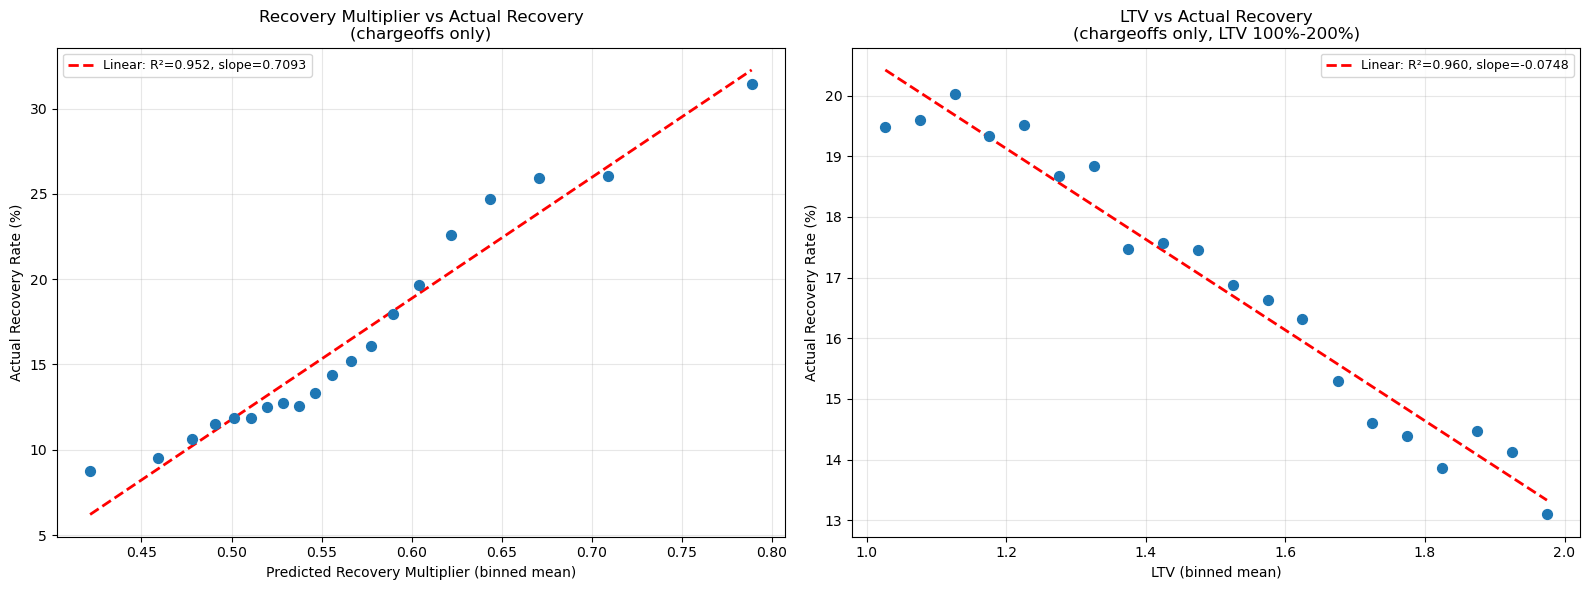

UNIVARIATE SLOPE COMPARISON (chargeoff population)

Predictor                           Slope    Intercept       R²   N bins
----------------------------------------------------------------------
Recovery Multiplier              +0.70933     -0.23690    0.952       20
LTV (100%-200%)                  -0.07482     +0.28106    0.960       20


In [6]:
LTV_MIN, LTV_MAX, LTV_STEP = 1.00, 2.00, 0.05
ltv_bins = np.arange(LTV_MIN, LTV_MAX + LTV_STEP, LTV_STEP)
ltv_labels = [f"{b:.0%}-{b + LTV_STEP:.0%}" for b in ltv_bins[:-1]]

co['ltv_band'] = pd.cut(co['ltv'], bins=ltv_bins, labels=ltv_labels, right=False)
co['rec_mult_quintile'] = pd.qcut(
    co['new_recovery_multiplier'], q=5,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']
)

# --- Recovery multiplier vs actual recovery ---
N_REC_BINS = 20
co['rec_mult_band'] = pd.qcut(co['new_recovery_multiplier'], q=N_REC_BINS, duplicates='drop')
rec_agg = co.groupby('rec_mult_band', observed=True).agg(
    rec_mult_mid=('new_recovery_multiplier', 'mean'),
    actual_recovery=('recovery_pct', 'mean'),
    loan_count=('account_number', 'count'),
    total_gl=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
rec_agg['weighted_recovery'] = (rec_agg['total_gl'] - rec_agg['total_cnl']) / rec_agg['total_proceeds']

slope_r, intercept_r, r_r, _, _ = linregress(rec_agg['rec_mult_mid'], rec_agg['weighted_recovery'])

# --- LTV vs actual recovery (chargeoffs only) ---
ltv_agg = co[co['ltv_band'].notna()].groupby('ltv_band', observed=True).agg(
    ltv_mid=('ltv', 'mean'),
    actual_recovery=('recovery_pct', 'mean'),
    loan_count=('account_number', 'count'),
    total_gl=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
).reset_index()
ltv_agg['weighted_recovery'] = (ltv_agg['total_gl'] - ltv_agg['total_cnl']) / ltv_agg['total_proceeds']

slope_l, intercept_l, r_l, _, _ = linregress(ltv_agg['ltv_mid'], ltv_agg['weighted_recovery'])

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(rec_agg['rec_mult_mid'], rec_agg['weighted_recovery'] * 100, s=50, zorder=3)
x_fit = np.linspace(rec_agg['rec_mult_mid'].min(), rec_agg['rec_mult_mid'].max(), 100)
ax.plot(x_fit, (intercept_r + slope_r * x_fit) * 100, 'r--', linewidth=2,
        label=f"Linear: R²={r_r**2:.3f}, slope={slope_r:.4f}")
ax.set_xlabel('Predicted Recovery Multiplier (binned mean)')
ax.set_ylabel('Actual Recovery Rate (%)')
ax.set_title('Recovery Multiplier vs Actual Recovery\n(chargeoffs only)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(ltv_agg['ltv_mid'], ltv_agg['weighted_recovery'] * 100, s=50, zorder=3)
x_fit = np.linspace(ltv_agg['ltv_mid'].min(), ltv_agg['ltv_mid'].max(), 100)
ax.plot(x_fit, (intercept_l + slope_l * x_fit) * 100, 'r--', linewidth=2,
        label=f"Linear: R²={r_l**2:.3f}, slope={slope_l:.4f}")
ax.set_xlabel('LTV (binned mean)')
ax.set_ylabel('Actual Recovery Rate (%)')
ax.set_title('LTV vs Actual Recovery\n(chargeoffs only, LTV 100%-200%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('univariate_recovery_slopes.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print("UNIVARIATE SLOPE COMPARISON (chargeoff population)")
print("=" * 80)
print(f"\n{'Predictor':<30} {'Slope':>10} {'Intercept':>12} {'R²':>8} {'N bins':>8}")
print("-" * 70)
print(f"{'Recovery Multiplier':<30} {slope_r:>+10.5f} {intercept_r:>+12.5f} {r_r**2:>8.3f} {len(rec_agg):>8}")
print(f"{'LTV (100%-200%)':<30} {slope_l:>+10.5f} {intercept_l:>+12.5f} {r_l**2:>8.3f} {len(ltv_agg):>8}")

In [7]:
co_valid = co[co['ltv_band'].notna() & co['new_recovery_multiplier'].notna()].copy()

y = co_valid['recovery_pct'].values
X_rec = co_valid['new_recovery_multiplier'].values.reshape(-1, 1)
X_ltv = co_valid['ltv'].values.reshape(-1, 1)
X_both = np.column_stack([co_valid['new_recovery_multiplier'], co_valid['ltv']])
X_inter = np.column_stack([
    co_valid['new_recovery_multiplier'],
    co_valid['ltv'],
    co_valid['new_recovery_multiplier'] * co_valid['ltv']
])

models = {}
specs = {
    'M1: Recovery Mult only':    X_rec,
    'M2: LTV only':              X_ltv,
    'M3: Additive (R + LTV)':    X_both,
    'M4: Coupled (R + LTV + RxLTV)': X_inter,
}

print("=" * 90)
print("LOAN-LEVEL REGRESSIONS: Actual Recovery ~ Predictors")
print(f"Population: {len(co_valid):,} chargeoffs with LTV in [100%, 200%) and recovery_multiplier")
print("=" * 90)
print(f"\n{'Model':<35} {'R²':>8} {'Adj R²':>8}  Coefficients")
print("-" * 90)

for name, X in specs.items():
    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)
    r2 = r2_score(y, y_pred)
    n, k = len(y), X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    models[name] = {'model': lr, 'r2': r2, 'adj_r2': adj_r2}

    coef_str = f"intercept={lr.intercept_:.6f}"
    labels = {
        'M1: Recovery Mult only':        ['R'],
        'M2: LTV only':                  ['LTV'],
        'M3: Additive (R + LTV)':        ['R', 'LTV'],
        'M4: Coupled (R + LTV + RxLTV)': ['R', 'LTV', 'RxLTV'],
    }
    for lbl, c in zip(labels[name], lr.coef_):
        coef_str += f", {lbl}={c:.6f}"

    print(f"{name:<35} {r2:>8.5f} {adj_r2:>8.5f}  {coef_str}")

# --- Binned regressions (for comparison with aggregated-data R²) ---
N_JOINT_BINS = 20
co_valid['rec_bin'] = pd.qcut(co_valid['new_recovery_multiplier'], q=N_JOINT_BINS, duplicates='drop')
co_valid['ltv_bin'] = pd.cut(co_valid['ltv'], bins=ltv_bins, right=False)

rec_binned = co_valid.groupby('rec_bin', observed=True).agg(
    R=('new_recovery_multiplier', 'mean'), recovery=('recovery_pct', 'mean')
).dropna()

ltv_binned = co_valid.groupby('ltv_bin', observed=True).agg(
    LTV=('ltv', 'mean'), recovery=('recovery_pct', 'mean')
).dropna()

# 2D bins for additive/coupled
joint = co_valid.groupby(['rec_bin', 'ltv_bin'], observed=True).agg(
    R=('new_recovery_multiplier', 'mean'),
    LTV=('ltv', 'mean'),
    recovery=('recovery_pct', 'mean'),
    n=('account_number', 'count'),
).dropna().reset_index()
joint = joint[joint['n'] >= 30]

print(f"\n{'=' * 90}")
print("BINNED REGRESSIONS (bin-level means, min 30 loans per cell)")
print(f"{'=' * 90}")
print(f"\n{'Model':<35} {'R²':>8} {'N bins':>8}")
print("-" * 55)

_, _, r_b1, _, _ = linregress(rec_binned['R'], rec_binned['recovery'])
print(f"{'M1: Recovery Mult only':<35} {r_b1**2:>8.3f} {len(rec_binned):>8}")

_, _, r_b2, _, _ = linregress(ltv_binned['LTV'], ltv_binned['recovery'])
print(f"{'M2: LTV only':<35} {r_b2**2:>8.3f} {len(ltv_binned):>8}")

if len(joint) >= 5:
    lr3 = LinearRegression().fit(joint[['R', 'LTV']], joint['recovery'])
    r2_b3 = r2_score(joint['recovery'], lr3.predict(joint[['R', 'LTV']]))
    print(f"{'M3: Additive (R + LTV)':<35} {r2_b3:>8.3f} {len(joint):>8}")

    joint['RxLTV'] = joint['R'] * joint['LTV']
    lr4 = LinearRegression().fit(joint[['R', 'LTV', 'RxLTV']], joint['recovery'])
    r2_b4 = r2_score(joint['recovery'], lr4.predict(joint[['R', 'LTV', 'RxLTV']]))
    print(f"{'M4: Coupled (R + LTV + RxLTV)':<35} {r2_b4:>8.3f} {len(joint):>8}")
else:
    print("  (insufficient joint bins for M3/M4)")

LOAN-LEVEL REGRESSIONS: Actual Recovery ~ Predictors
Population: 146,571 chargeoffs with LTV in [100%, 200%) and recovery_multiplier

Model                                     R²   Adj R²  Coefficients
------------------------------------------------------------------------------------------
M1: Recovery Mult only               0.07279  0.07279  intercept=-0.254023, R=0.753148


M2: LTV only                         0.00658  0.00657  intercept=0.287022, LTV=-0.080335
M3: Additive (R + LTV)               0.07738  0.07737  intercept=-0.151331, R=0.743703, LTV=-0.067175
M4: Coupled (R + LTV + RxLTV)        0.07741  0.07739  intercept=-0.103857, R=0.659768, LTV=-0.100289, RxLTV=0.058629



BINNED REGRESSIONS (bin-level means, min 30 loans per cell)

Model                                     R²   N bins
-------------------------------------------------------
M1: Recovery Mult only                 0.953       20


M2: LTV only                           0.975       20
M3: Additive (R + LTV)                 0.921      400
M4: Coupled (R + LTV + RxLTV)          0.921      400


In [8]:
m3 = models['M3: Additive (R + LTV)']['model']
beta_R_raw = m3.coef_[0]
beta_LTV_raw = m3.coef_[1]

std_R = co_valid['new_recovery_multiplier'].std()
std_LTV = co_valid['ltv'].std()
std_y = co_valid['recovery_pct'].std()

beta_R_std = beta_R_raw * std_R / std_y
beta_LTV_std = abs(beta_LTV_raw) * std_LTV / std_y

print("=" * 80)
print("STANDARDIZED COEFFICIENT COMPARISON (M3: R + LTV)")
print("Standardized beta = raw_coef * std(X) / std(Y)")
print("Measures: per 1-SD change in predictor, how many SDs does recovery move?")
print("=" * 80)

print(f"\n{'':>30} {'Raw Coef':>12} {'std(X)':>10} {'Std Beta':>12} {'Relative':>10}")
print("-" * 78)
print(f"{'Recovery Multiplier (R)':<30} {beta_R_raw:>+12.6f} {std_R:>10.4f} {beta_R_std:>12.4f} {'1.00x':>10}")
print(f"{'LTV':<30} {beta_LTV_raw:>+12.6f} {std_LTV:>10.4f} {beta_LTV_std:>12.4f} {f'{beta_LTV_std/beta_R_std:.2f}x':>10}")

# Practical importance: ppts of recovery change per 1-SD predictor change
delta_R_per_sd = abs(beta_R_raw) * std_R * 100
delta_LTV_per_sd = abs(beta_LTV_raw) * std_LTV * 100

print(f"\n{'':>30} {'ppts recovery per 1-SD':>25}")
print("-" * 58)
print(f"{'Recovery Multiplier (R)':<30} {delta_R_per_sd:>25.2f}")
print(f"{'LTV':<30} {delta_LTV_per_sd:>25.2f}")
print(f"{'Ratio (R / LTV)':<30} {delta_R_per_sd/delta_LTV_per_sd:>25.2f}x")

print(f"\n--- Interpretation ---")
print(f"  Raw coefficients (R=0.744 vs LTV=0.067) exaggerate R's advantage")
print(f"  because R and LTV are on different scales.")
print(f"  Standardized: a 1-SD swing in R moves recovery by {delta_R_per_sd:.2f} ppts,")
print(f"  vs {delta_LTV_per_sd:.2f} ppts for a 1-SD swing in LTV.")
print(f"  Per unit of natural variation, R is {delta_R_per_sd/delta_LTV_per_sd:.1f}x more")
print(f"  influential than LTV -- not 11x.")

STANDARDIZED COEFFICIENT COMPARISON (M3: R + LTV)
Standardized beta = raw_coef * std(X) / std(Y)
Measures: per 1-SD change in predictor, how many SDs does recovery move?

                                   Raw Coef     std(X)     Std Beta   Relative
------------------------------------------------------------------------------
Recovery Multiplier (R)           +0.743703     0.0885       0.2664      1.00x
LTV                               -0.067175     0.2495       0.0678      0.25x

                                  ppts recovery per 1-SD
----------------------------------------------------------
Recovery Multiplier (R)                             6.58
LTV                                                 1.68
Ratio (R / LTV)                                     3.93x

--- Interpretation ---
  Raw coefficients (R=0.744 vs LTV=0.067) exaggerate R's advantage
  because R and LTV are on different scales.
  Standardized: a 1-SD swing in R moves recovery by 6.58 ppts,
  vs 1.68 ppts for a 1-SD

In [9]:
print("=" * 80)
print("RAGU FORMULA DERIVATION: Recovery and LTV Impacts")
print("Convention: 1 RAGU point = 1 ppt lower CNL (as % of proceeds)")
print("=" * 80)

F_empirical = beta_R_raw
F_theoretical = 0.75
beta_ltv_chargeoff = abs(beta_LTV_raw)

print(f"\n--- Empirical Validation of V2 Theoretical Structure ---")
print(f"  V2 theory: recovery_per_chargeoff = F * R, with F = {F_theoretical}")
print(f"  Empirical: M3 coefficient on R = {F_empirical:.4f}")
print(f"  Match: {F_empirical/F_theoretical:.1%} of theoretical F")
print(f"  -> V2 recovery structure (UL * F * R) is empirically validated.")

print(f"\n--- V2-Compatible Formulas (decoupled, theoretical structure) ---")
print(f"""
  recovery_impact = UL * F * R * recovery_to_score
  ltv_impact      = UL * F * beta_ltv * (LTV_baseline - LTV) * recovery_to_score

  where:
    F               = {F_theoretical}         (empirical: {F_empirical:.4f})
    beta_ltv        = {beta_ltv_chargeoff/F_empirical:.4f}      (= {beta_ltv_chargeoff:.4f} / {F_empirical:.4f})
    recovery_to_score = free calibration parameter (converts recovery to RAGU points)

  Note: beta_ltv = {beta_ltv_chargeoff:.4f} / {F_empirical:.4f} = {beta_ltv_chargeoff/F_empirical:.4f}
  This is the LTV effect expressed relative to R, so both terms share
  the same UL * F * recovery_to_score scaling.
""")

print(f"--- Calibrating recovery_to_score ---")
print(f"  If 1 RAGU point = 1 ppt (0.01) of CNL/proceeds:")
print(f"    recovery_to_score = 1 / 0.01 = 100")
print(f"")
print(f"  Example (UL=0.50, F=0.75, R=0.55, LTV=1.50, LTV_baseline=1.94):")

UL_ex, R_ex, LTV_ex, LTV_base_ex = 0.50, 0.55, 1.50, 1.94
rec_to_score = 100
beta_ltv_rel = beta_ltv_chargeoff / F_empirical

rec_impact_ex = UL_ex * F_theoretical * R_ex * rec_to_score
ltv_impact_ex = UL_ex * F_theoretical * beta_ltv_rel * (LTV_base_ex - LTV_ex) * rec_to_score

print(f"    recovery_impact = {UL_ex} * {F_theoretical} * {R_ex} * {rec_to_score} = {rec_impact_ex:.1f} pts")
print(f"    ltv_impact      = {UL_ex} * {F_theoretical} * {beta_ltv_rel:.4f} * ({LTV_base_ex} - {LTV_ex}) * {rec_to_score} = {ltv_impact_ex:.1f} pts")

print(f"\n--- Comparison with V1/V2 multipliers ---")
print(f"  {'Component':<20} {'V1':>12} {'V2':>12} {'Empirical':>12}")
print(f"  {'-'*58}")
print(f"  {'LTV form':<20} {'(B/LTV-1)*17':>12} {'(B-LTV)*17':>12} {'see above':>12}")
print(f"  {'LTV eff. mult':<20} {'17':>12} {'17':>12} {f'UL*F*{beta_ltv_rel:.3f}*100':>12}")
print(f"  {'Recovery form':<20} {'complex':>12} {'UL*F*R/0.027':>12} {'UL*F*R*100':>12}")
print(f"  {'Find rate (F)':<20} {'implicit':>12} {'0.75':>12} {f'{F_empirical:.3f}':>12}")

RAGU FORMULA DERIVATION: Recovery and LTV Impacts
Convention: 1 RAGU point = 1 ppt lower CNL (as % of proceeds)

--- Empirical Validation of V2 Theoretical Structure ---
  V2 theory: recovery_per_chargeoff = F * R, with F = 0.75
  Empirical: M3 coefficient on R = 0.7437
  Match: 99.2% of theoretical F
  -> V2 recovery structure (UL * F * R) is empirically validated.

--- V2-Compatible Formulas (decoupled, theoretical structure) ---

  recovery_impact = UL * F * R * recovery_to_score
  ltv_impact      = UL * F * beta_ltv * (LTV_baseline - LTV) * recovery_to_score

  where:
    F               = 0.75         (empirical: 0.7437)
    beta_ltv        = 0.0903      (= 0.0672 / 0.7437)
    recovery_to_score = free calibration parameter (converts recovery to RAGU points)

  Note: beta_ltv = 0.0672 / 0.7437 = 0.0903
  This is the LTV effect expressed relative to R, so both terms share
  the same UL * F * recovery_to_score scaling.

--- Calibrating recovery_to_score ---
  If 1 RAGU point = 1 ppt

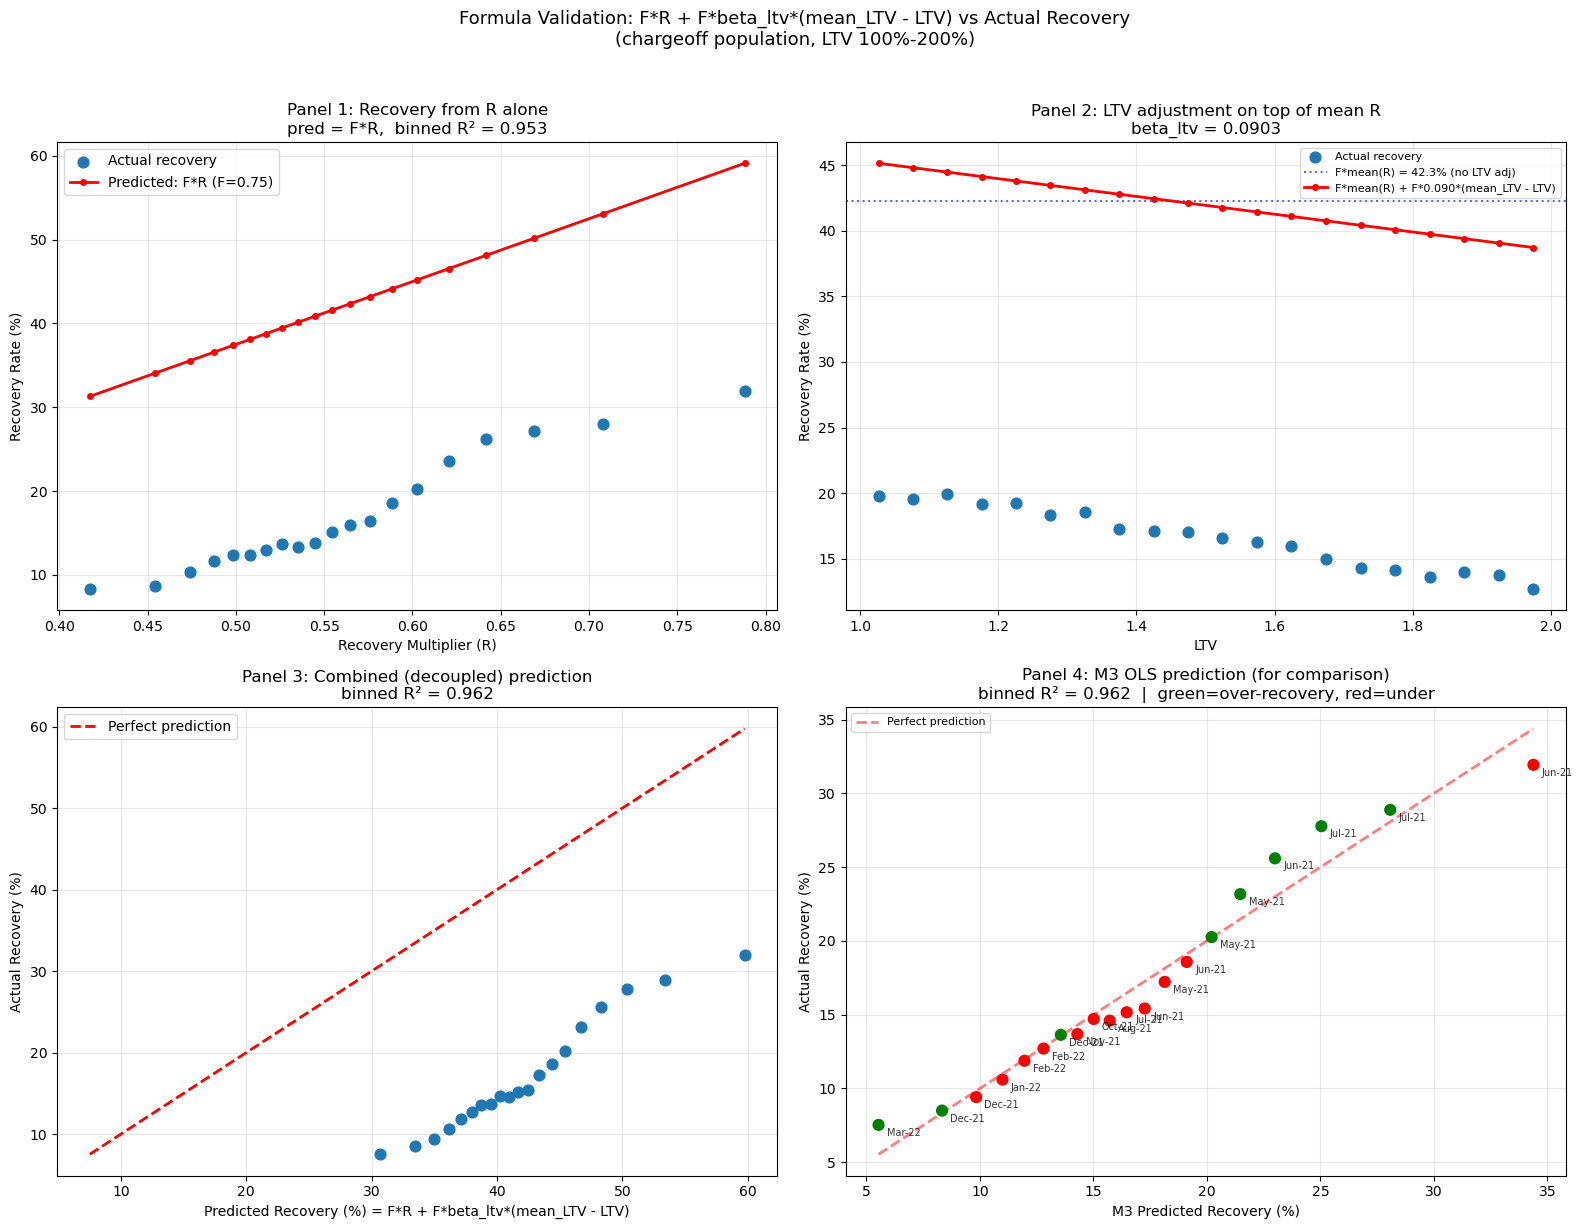

FORMULA VALIDATION SUMMARY

  Formula: pred_recovery = F*R + F*beta_ltv*(mean_LTV - LTV)
    F = 0.75,  beta_ltv = 0.0903

  Prediction                                     Binned R²
  ----------------------------------------------------------
  Panel 1: F*R alone (binned by R)                   0.953
  Panel 3: F*R + F*beta_ltv*dLTV (combined)          0.962
  Panel 4: M3 OLS (intercept + R + LTV)              0.962

  Mean actual recovery (chargeoffs): 17.06%
  Mean predicted (F*R):              42.28%
  Mean predicted (combined):         42.28%
  Mean predicted (M3):               17.06%


In [10]:
F = 0.75
beta_ltv = abs(beta_LTV_raw) / beta_R_raw

m3_intercept = m3.intercept_
m3_R_coef = m3.coef_[0]
m3_LTV_coef = m3.coef_[1]

mean_R = co_valid['new_recovery_multiplier'].mean()
mean_LTV = co_valid['ltv'].mean()

# Predicted components for each loan (chargeoff-conditional)
co_valid = co_valid.copy()
co_valid['pred_from_R'] = F * co_valid['new_recovery_multiplier']
co_valid['pred_from_LTV'] = beta_ltv * (mean_LTV - co_valid['ltv']) * F
co_valid['pred_combined'] = co_valid['pred_from_R'] + co_valid['pred_from_LTV']

# M3 regression prediction for comparison
co_valid['pred_m3'] = m3.predict(
    co_valid[['new_recovery_multiplier', 'ltv']].values
)

# --- Panel 1: Recovery contribution from R (bin by R) ---
N_BINS = 20
co_valid['R_bin'] = pd.qcut(co_valid['new_recovery_multiplier'], q=N_BINS, duplicates='drop')
by_R = co_valid.groupby('R_bin', observed=True).agg(
    R_mid=('new_recovery_multiplier', 'mean'),
    actual=('recovery_pct', 'mean'),
    pred_R=('pred_from_R', 'mean'),
    n=('account_number', 'count'),
).dropna()

# --- Panel 2: Recovery contribution from LTV (bin by LTV) ---
co_valid['LTV_bin'] = pd.cut(co_valid['ltv'], bins=ltv_bins, right=False)
by_LTV = co_valid[co_valid['LTV_bin'].notna()].groupby('LTV_bin', observed=True).agg(
    LTV_mid=('ltv', 'mean'),
    actual=('recovery_pct', 'mean'),
    pred_LTV_component=('pred_from_LTV', 'mean'),
    pred_R_at_mean=('pred_from_R', 'mean'),
    n=('account_number', 'count'),
).dropna()

# --- Panel 3: Combined prediction (bin by predicted combined) ---
co_valid['combined_bin'] = pd.qcut(co_valid['pred_combined'], q=N_BINS, duplicates='drop')
by_combined = co_valid.groupby('combined_bin', observed=True).agg(
    pred_mid=('pred_combined', 'mean'),
    actual=('recovery_pct', 'mean'),
    pred_m3_mean=('pred_m3', 'mean'),
    n=('account_number', 'count'),
).dropna()

# --- Panel 4: M3 regression prediction + median book_date ---
co_valid['m3_bin'] = pd.qcut(co_valid['pred_m3'], q=N_BINS, duplicates='drop')
co_valid['book_date_dt'] = pd.to_datetime(co_valid['book_date'])
co_valid['book_date_ordinal'] = co_valid['book_date_dt'].apply(lambda x: x.toordinal())
by_m3 = co_valid.groupby('m3_bin', observed=True).agg(
    pred_mid=('pred_m3', 'mean'),
    actual=('recovery_pct', 'mean'),
    median_ordinal=('book_date_ordinal', 'median'),
    n=('account_number', 'count'),
).dropna()
from datetime import date as dt_date
by_m3['median_book_date'] = by_m3['median_ordinal'].apply(
    lambda x: pd.Timestamp(dt_date.fromordinal(int(x)))
)

# --- R² for each ---
from scipy.stats import linregress as lr_func
_, _, r_panel1, _, _ = lr_func(by_R['pred_R'], by_R['actual'])
_, _, r_panel3, _, _ = lr_func(by_combined['pred_mid'], by_combined['actual'])
_, _, r_panel4, _, _ = lr_func(by_m3['pred_mid'], by_m3['actual'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: R contribution
ax = axes[0, 0]
ax.scatter(by_R['R_mid'], by_R['actual'] * 100, s=60, label='Actual recovery', zorder=3)
ax.plot(by_R['R_mid'], by_R['pred_R'] * 100, 'r-o', markersize=4, linewidth=2,
        label=f'Predicted: F*R (F={F})')
ax.set_xlabel('Recovery Multiplier (R)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title(f'Panel 1: Recovery from R alone\npred = F*R,  binned R² = {r_panel1**2:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: LTV contribution (show actual recovery vs LTV, with F*R component)
ax = axes[0, 1]
ax.scatter(by_LTV['LTV_mid'], by_LTV['actual'] * 100, s=60, label='Actual recovery', zorder=3)
# Show what F*mean(R) predicts (flat line) vs the LTV adjustment
mean_pred_R = F * mean_R
ax.axhline(mean_pred_R * 100, color='blue', linestyle=':', alpha=0.6,
           label=f'F*mean(R) = {mean_pred_R*100:.1f}% (no LTV adj)')
ltv_x = by_LTV['LTV_mid'].values
ltv_pred = (mean_pred_R + F * beta_ltv * (mean_LTV - ltv_x)) * 100
ax.plot(ltv_x, ltv_pred, 'r-o', markersize=4, linewidth=2,
        label=f'F*mean(R) + F*{beta_ltv:.3f}*(mean_LTV - LTV)')
ax.set_xlabel('LTV')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title(f'Panel 2: LTV adjustment on top of mean R\nbeta_ltv = {beta_ltv:.4f}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Combined F*R + F*beta_ltv*(mean_LTV - LTV)
ax = axes[1, 0]
ax.scatter(by_combined['pred_mid'] * 100, by_combined['actual'] * 100, s=60, zorder=3)
min_v = min(by_combined['pred_mid'].min(), by_combined['actual'].min()) * 100
max_v = max(by_combined['pred_mid'].max(), by_combined['actual'].max()) * 100
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Predicted Recovery (%) = F*R + F*beta_ltv*(mean_LTV - LTV)')
ax.set_ylabel('Actual Recovery (%)')
ax.set_title(f'Panel 3: Combined (decoupled) prediction\nbinned R² = {r_panel3**2:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 4: M3 regression for comparison, with median book_date annotations
ax = axes[1, 1]
residuals_m3 = by_m3['actual'] - by_m3['pred_mid']
colors_m3 = ['green' if r > 0 else 'red' for r in residuals_m3]
ax.scatter(by_m3['pred_mid'] * 100, by_m3['actual'] * 100, s=60, c=colors_m3, zorder=3)
min_v = min(by_m3['pred_mid'].min(), by_m3['actual'].min()) * 100
max_v = max(by_m3['pred_mid'].max(), by_m3['actual'].max()) * 100
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, alpha=0.5, label='Perfect prediction')
for _, row in by_m3.iterrows():
    date_label = row['median_book_date'].strftime('%b-%y')
    ax.annotate(date_label,
                (row['pred_mid'] * 100, row['actual'] * 100),
                textcoords="offset points", xytext=(6, -8),
                fontsize=7, alpha=0.8)
ax.set_xlabel('M3 Predicted Recovery (%)')
ax.set_ylabel('Actual Recovery (%)')
ax.set_title(f'Panel 4: M3 OLS prediction (for comparison)\nbinned R² = {r_panel4**2:.3f}  |  green=over-recovery, red=under')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Formula Validation: F*R + F*beta_ltv*(mean_LTV - LTV) vs Actual Recovery\n'
             '(chargeoff population, LTV 100%-200%)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('formula_validation_recovery_ltv.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print("FORMULA VALIDATION SUMMARY")
print("=" * 80)
print(f"\n  Formula: pred_recovery = F*R + F*beta_ltv*(mean_LTV - LTV)")
print(f"    F = {F},  beta_ltv = {beta_ltv:.4f}")
print(f"\n  {'Prediction':<45} {'Binned R²':>10}")
print(f"  {'-'*58}")
print(f"  {'Panel 1: F*R alone (binned by R)':<45} {r_panel1**2:>10.3f}")
print(f"  {'Panel 3: F*R + F*beta_ltv*dLTV (combined)':<45} {r_panel3**2:>10.3f}")
print(f"  {'Panel 4: M3 OLS (intercept + R + LTV)':<45} {r_panel4**2:>10.3f}")
print(f"\n  Mean actual recovery (chargeoffs): {co_valid['recovery_pct'].mean()*100:.2f}%")
print(f"  Mean predicted (F*R):              {(F * mean_R)*100:.2f}%")
print(f"  Mean predicted (combined):         {co_valid['pred_combined'].mean()*100:.2f}%")
print(f"  Mean predicted (M3):               {co_valid['pred_m3'].mean()*100:.2f}%")

RECOVERY RATE (%) = (Gross Loss - CNL) / Proceeds  --  CHARGEOFFS ONLY
Rows: LTV 5% bands | Columns: Recovery Multiplier quintiles


rec_mult_quintile,"Q1 (Low)\n[0.273, 0.496]","Q2\n[0.496, 0.533]","Q3\n[0.533, 0.572]","Q4\n[0.572, 0.632]","Q5 (High)\n[0.632, 1.052]"
ltv_band,,,,,
100%-105%,12.201,14.630,18.413,21.064,28.166
105%-110%,14.224,14.472,16.264,21.329,28.459
110%-115%,13.361,15.249,17.161,22.085,28.666
115%-120%,12.364,14.961,15.811,22.226,28.652
120%-125%,13.027,15.356,16.432,21.481,29.608
125%-130%,12.145,14.818,16.603,20.537,28.360
130%-135%,11.609,14.635,16.103,20.999,31.178
135%-140%,11.229,13.732,14.899,20.154,28.017
140%-145%,10.492,14.571,14.095,21.087,28.499



LOAN COUNT  --  CHARGEOFFS ONLY
Rows: LTV 5% bands | Columns: Recovery Multiplier quintiles


rec_mult_quintile,"Q1 (Low)\n[0.273, 0.496]","Q2\n[0.496, 0.533]","Q3\n[0.533, 0.572]","Q4\n[0.572, 0.632]","Q5 (High)\n[0.632, 1.052]"
ltv_band,,,,,
100%-105%,797,728,748,838,931
105%-110%,1084,1041,1025,1109,1278
110%-115%,1328,1347,1325,1452,1685
115%-120%,1632,1824,1688,1856,1892
120%-125%,1959,2062,2043,2089,2147
125%-130%,2257,2308,2163,2258,2217
130%-135%,2408,2300,2206,2202,2160
135%-140%,2390,2163,2176,2169,2052
140%-145%,2341,2022,2116,2045,1938


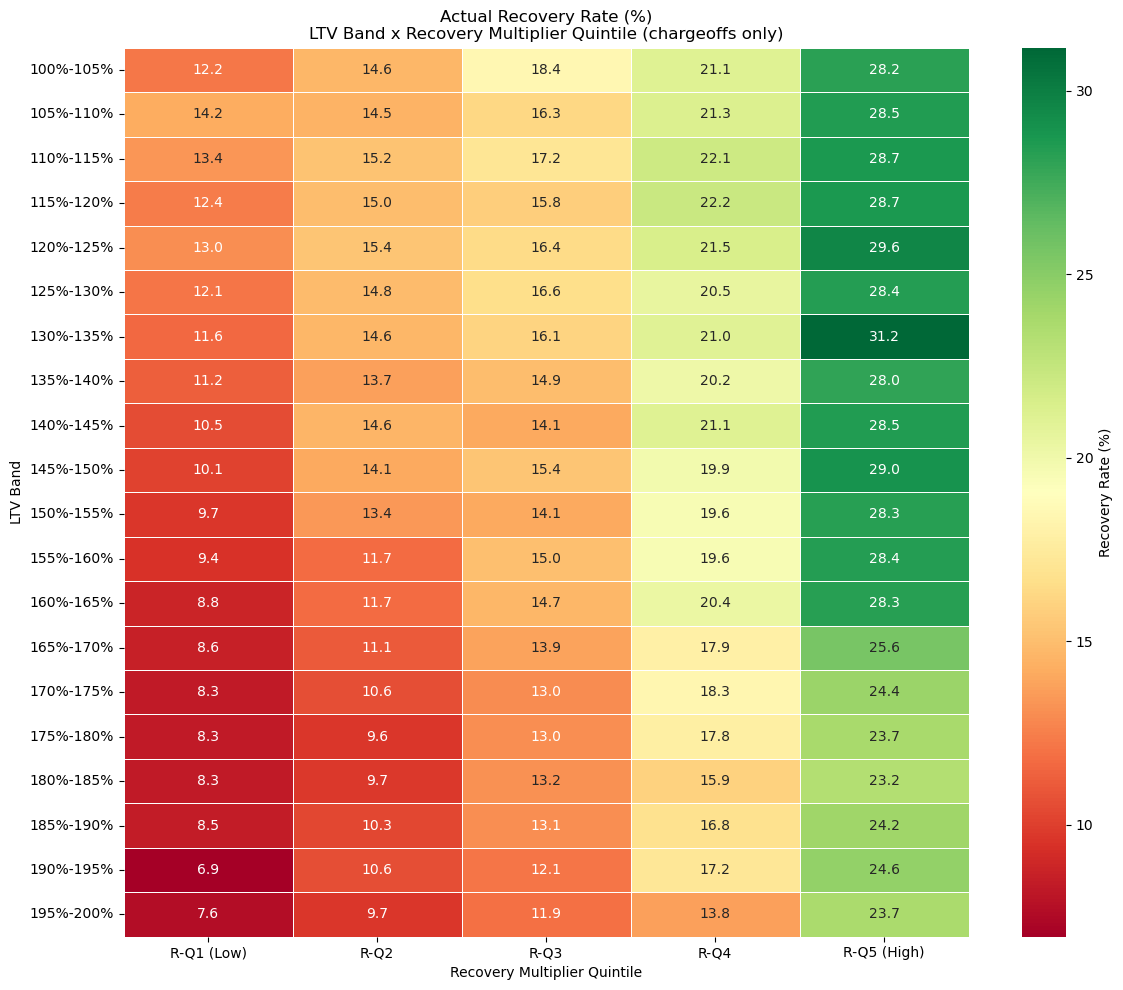

In [11]:
analysis_co = co[co['ltv_band'].notna() & co['rec_mult_quintile'].notna()].copy()

q_ranges = analysis_co.groupby('rec_mult_quintile', observed=True)['new_recovery_multiplier'].agg(['min', 'max', 'count'])
q_ranges['col_label'] = q_ranges.apply(lambda r: f"[{r['min']:.3f}, {r['max']:.3f}]", axis=1)

grouped = analysis_co.groupby(['ltv_band', 'rec_mult_quintile'], observed=True).agg(
    total_gross_loss=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    loan_count=('account_number', 'count')
).reset_index()

grouped['recovery_rate'] = (grouped['total_gross_loss'] - grouped['total_cnl']) / grouped['total_proceeds']

pivot_rate = grouped.pivot(index='ltv_band', columns='rec_mult_quintile', values='recovery_rate')
display_rate = pivot_rate.copy() * 100
col_rename = {q: f"{q}\n{q_ranges.loc[q, 'col_label']}" for q in q_ranges.index}
display_rate = display_rate.rename(columns=col_rename)

print("=" * 90)
print("RECOVERY RATE (%) = (Gross Loss - CNL) / Proceeds  --  CHARGEOFFS ONLY")
print("Rows: LTV 5% bands | Columns: Recovery Multiplier quintiles")
print("=" * 90)
display(display_rate.round(3))

pivot_count = grouped.pivot(index='ltv_band', columns='rec_mult_quintile', values='loan_count')
display_count = pivot_count.rename(columns=col_rename)

print(f"\n{'=' * 90}")
print("LOAN COUNT  --  CHARGEOFFS ONLY")
print("Rows: LTV 5% bands | Columns: Recovery Multiplier quintiles")
print("=" * 90)
display(display_count)

# --- Heatmap ---
heatmap_data = pivot_rate.copy() * 100
heatmap_data.columns = [f"R-{c}" for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Recovery Rate (%)'})
ax.set_title('Actual Recovery Rate (%)\nLTV Band x Recovery Multiplier Quintile (chargeoffs only)')
ax.set_xlabel('Recovery Multiplier Quintile')
ax.set_ylabel('LTV Band')
plt.tight_layout()
plt.savefig('recovery_heatmap_ltv_x_recmult.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
corr = co['ltv'].corr(co['new_recovery_multiplier'])
print("=" * 80)
print("ORTHOGONALITY DIAGNOSTICS")
print("=" * 80)
print(f"\nLoan-level Pearson correlation (LTV, recovery_multiplier): {corr:.4f}")
print(f"  Interpretation: {'Low' if abs(corr) < 0.3 else 'Moderate' if abs(corr) < 0.6 else 'High'}"
      f" correlation -> {'supports decoupling' if abs(corr) < 0.3 else 'some overlap' if abs(corr) < 0.6 else 'redundancy concern'}")

# --- Slope of recovery vs LTV within each recovery_multiplier quintile ---
print(f"\n{'=' * 80}")
print("REGRESSION: Recovery Rate vs LTV within each Recovery Multiplier Quintile")
print("=" * 80)
print(f"\n{'Quintile':<15} {'Slope (dR/dLTV)':>18} {'Intercept':>12} {'R²':>8} {'N bands':>8}")
print("-" * 65)

for quintile in pivot_rate.columns:
    col = pivot_rate[quintile]
    valid = col.dropna()
    if len(valid) < 3:
        print(f"{quintile:<15} {'insufficient data'}")
        continue

    ltv_midpoints = np.array([
        LTV_MIN + i * LTV_STEP + LTV_STEP / 2
        for i, lbl in enumerate(ltv_labels) if lbl in valid.index
    ])
    y_vals = valid.values
    slope, intercept, r_value, _, _ = linregress(ltv_midpoints, y_vals)
    print(f"{quintile:<15} {slope:>+18.6f} {intercept:>+12.6f} {r_value**2:>8.3f} {len(valid):>8}")

# --- Slope of recovery vs recovery_multiplier within each LTV band ---
print(f"\n{'=' * 80}")
print("REGRESSION: Recovery Rate vs Recovery Multiplier within each LTV Band")
print("(using quintile midpoints as X)")
print("=" * 80)
print(f"\n{'LTV Band':<15} {'Slope (dR/dRecMult)':>22} {'R²':>8} {'N quintiles':>12}")
print("-" * 60)

q_mids = analysis_co.groupby('rec_mult_quintile', observed=True)['new_recovery_multiplier'].mean()

for ltv_band in list(pivot_rate.index)[:20]:
    row = pivot_rate.loc[ltv_band]
    valid = row.dropna()
    if len(valid) < 3:
        continue
    x = np.array([q_mids[q] for q in valid.index])
    y_vals = valid.values
    slope, intercept, r_value, _, _ = linregress(x, y_vals)
    print(f"{ltv_band:<15} {slope:>+22.6f} {r_value**2:>8.3f} {len(valid):>12}")

# --- Slope variation diagnostic ---
print(f"\n{'=' * 80}")
print("SLOPE VARIATION: Does the LTV slope change across recovery_multiplier quintiles?")
print("=" * 80)
slopes_by_q = []
for quintile in pivot_rate.columns:
    col = pivot_rate[quintile]
    valid = col.dropna()
    if len(valid) < 3:
        continue
    ltv_midpoints = np.array([
        LTV_MIN + i * LTV_STEP + LTV_STEP / 2
        for i, lbl in enumerate(ltv_labels) if lbl in valid.index
    ])
    slope, _, _, _, _ = linregress(ltv_midpoints, valid.values)
    slopes_by_q.append({'quintile': quintile, 'slope': slope})

slopes_df = pd.DataFrame(slopes_by_q)
slope_range = slopes_df['slope'].max() - slopes_df['slope'].min()
slope_cv = slopes_df['slope'].std() / abs(slopes_df['slope'].mean())

print(f"\n  Slope range: {slopes_df['slope'].min():.6f} to {slopes_df['slope'].max():.6f}")
print(f"  Range width: {slope_range:.6f}")
print(f"  CV of slopes: {slope_cv:.3f}")
print(f"\n  Interpretation: {'Slopes are stable across quintiles -> additive structure is appropriate' if slope_cv < 0.3 else 'Slopes vary meaningfully -> interaction term may be warranted'}")

ORTHOGONALITY DIAGNOSTICS

Loan-level Pearson correlation (LTV, recovery_multiplier): -0.0095
  Interpretation: Low correlation -> supports decoupling

REGRESSION: Recovery Rate vs LTV within each Recovery Multiplier Quintile

Quintile           Slope (dR/dLTV)    Intercept       R²  N bands
-----------------------------------------------------------------
Q1 (Low)                 -0.069179    +0.206392    0.925       20
Q2                       -0.067291    +0.228429    0.861       20
Q3                       -0.056401    +0.232139    0.892       20
Q4                       -0.068472    +0.296786    0.814       20
Q5 (High)                -0.064384    +0.368044    0.652       20

REGRESSION: Recovery Rate vs Recovery Multiplier within each LTV Band
(using quintile midpoints as X)

LTV Band           Slope (dR/dRecMult)       R²  N quintiles
------------------------------------------------------------
100%-105%                    +0.673468    0.993            5
105%-110%               

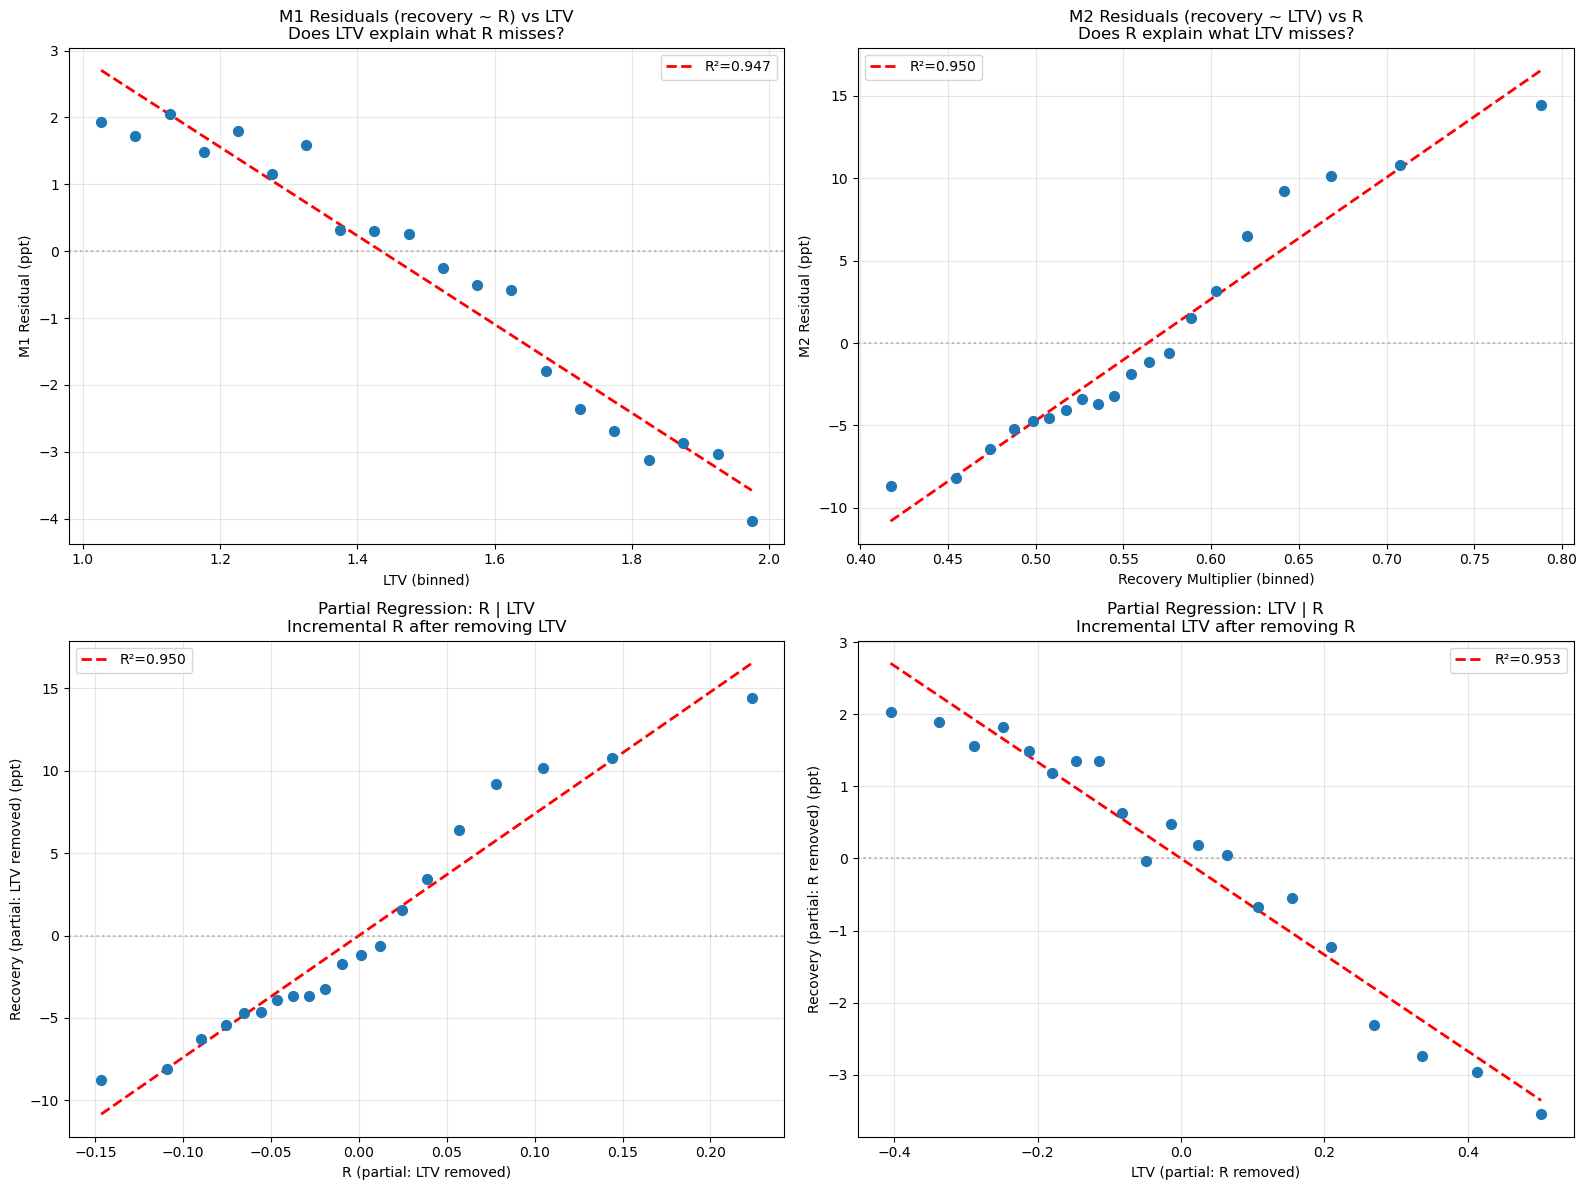

RESIDUAL & PARTIAL REGRESSION SUMMARY

Analysis                                                 R²
------------------------------------------------------------
M1 residuals (recovery~R) vs LTV (binned)             0.947
M2 residuals (recovery~LTV) vs R (binned)             0.950
Partial regression: R | LTV                           0.950
Partial regression: LTV | R                           0.953

Interpretation:
  - M1 residual R² = 0.947: LTV explains significant remaining variance after recovery_multiplier
  - M2 residual R² = 0.950: recovery_multiplier explains significant remaining variance after LTV


In [13]:
co_resid = co_valid.copy()

# M1 residuals: regress recovery on recovery_multiplier, check if LTV explains residuals
lr_m1 = LinearRegression().fit(
    co_resid['new_recovery_multiplier'].values.reshape(-1, 1),
    co_resid['recovery_pct'].values
)
co_resid['resid_m1'] = co_resid['recovery_pct'] - lr_m1.predict(
    co_resid['new_recovery_multiplier'].values.reshape(-1, 1)
)

# M2 residuals: regress recovery on LTV, check if recovery_multiplier explains residuals
lr_m2 = LinearRegression().fit(
    co_resid['ltv'].values.reshape(-1, 1),
    co_resid['recovery_pct'].values
)
co_resid['resid_m2'] = co_resid['recovery_pct'] - lr_m2.predict(
    co_resid['ltv'].values.reshape(-1, 1)
)

# Binned residual analysis for cleaner plots
N_RESID_BINS = 20

# Residuals from M1, binned by LTV
co_resid['ltv_bin_resid'] = pd.cut(co_resid['ltv'], bins=ltv_bins, right=False)
resid1_by_ltv = co_resid.groupby('ltv_bin_resid', observed=True).agg(
    ltv_mid=('ltv', 'mean'),
    mean_resid=('resid_m1', 'mean'),
    n=('account_number', 'count'),
).dropna()

slope_r1, intercept_r1, r_r1, _, _ = linregress(resid1_by_ltv['ltv_mid'], resid1_by_ltv['mean_resid'])

# Residuals from M2, binned by recovery_multiplier
co_resid['rec_bin_resid'] = pd.qcut(co_resid['new_recovery_multiplier'], q=N_RESID_BINS, duplicates='drop')
resid2_by_rec = co_resid.groupby('rec_bin_resid', observed=True).agg(
    rec_mid=('new_recovery_multiplier', 'mean'),
    mean_resid=('resid_m2', 'mean'),
    n=('account_number', 'count'),
).dropna()

slope_r2, intercept_r2, r_r2, _, _ = linregress(resid2_by_rec['rec_mid'], resid2_by_rec['mean_resid'])

# --- Partial regression (added-variable) plots ---
# Partial out LTV from recovery_multiplier
lr_r_on_ltv = LinearRegression().fit(co_resid[['ltv']], co_resid['new_recovery_multiplier'])
co_resid['R_partial'] = co_resid['new_recovery_multiplier'] - lr_r_on_ltv.predict(co_resid[['ltv']])

# Partial out recovery_multiplier from LTV
lr_ltv_on_r = LinearRegression().fit(co_resid[['new_recovery_multiplier']], co_resid['ltv'])
co_resid['LTV_partial'] = co_resid['ltv'] - lr_ltv_on_r.predict(co_resid[['new_recovery_multiplier']])

# Partial out LTV from recovery
lr_y_on_ltv = LinearRegression().fit(co_resid[['ltv']], co_resid['recovery_pct'])
co_resid['y_partial_ltv'] = co_resid['recovery_pct'] - lr_y_on_ltv.predict(co_resid[['ltv']])

# Partial out recovery_multiplier from recovery
lr_y_on_r = LinearRegression().fit(co_resid[['new_recovery_multiplier']], co_resid['recovery_pct'])
co_resid['y_partial_r'] = co_resid['recovery_pct'] - lr_y_on_r.predict(co_resid[['new_recovery_multiplier']])

# Bin partial values
co_resid['R_partial_bin'] = pd.qcut(co_resid['R_partial'], q=N_RESID_BINS, duplicates='drop')
partial_r = co_resid.groupby('R_partial_bin', observed=True).agg(
    x=('R_partial', 'mean'), y=('y_partial_ltv', 'mean')
).dropna()

co_resid['LTV_partial_bin'] = pd.qcut(co_resid['LTV_partial'], q=N_RESID_BINS, duplicates='drop')
partial_ltv = co_resid.groupby('LTV_partial_bin', observed=True).agg(
    x=('LTV_partial', 'mean'), y=('y_partial_r', 'mean')
).dropna()

slope_pr, _, r_pr, _, _ = linregress(partial_r['x'], partial_r['y'])
slope_pl, _, r_pl, _, _ = linregress(partial_ltv['x'], partial_ltv['y'])

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
ax.scatter(resid1_by_ltv['ltv_mid'], resid1_by_ltv['mean_resid'] * 100, s=50, zorder=3)
x_fit = np.linspace(resid1_by_ltv['ltv_mid'].min(), resid1_by_ltv['ltv_mid'].max(), 100)
ax.plot(x_fit, (intercept_r1 + slope_r1 * x_fit) * 100, 'r--', linewidth=2,
        label=f"R²={r_r1**2:.3f}")
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('LTV (binned)')
ax.set_ylabel('M1 Residual (ppt)')
ax.set_title('M1 Residuals (recovery ~ R) vs LTV\nDoes LTV explain what R misses?')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(resid2_by_rec['rec_mid'], resid2_by_rec['mean_resid'] * 100, s=50, zorder=3)
x_fit = np.linspace(resid2_by_rec['rec_mid'].min(), resid2_by_rec['rec_mid'].max(), 100)
ax.plot(x_fit, (intercept_r2 + slope_r2 * x_fit) * 100, 'r--', linewidth=2,
        label=f"R²={r_r2**2:.3f}")
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Recovery Multiplier (binned)')
ax.set_ylabel('M2 Residual (ppt)')
ax.set_title('M2 Residuals (recovery ~ LTV) vs R\nDoes R explain what LTV misses?')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.scatter(partial_r['x'], partial_r['y'] * 100, s=50, zorder=3)
x_fit = np.linspace(partial_r['x'].min(), partial_r['x'].max(), 100)
ax.plot(x_fit, (partial_r['y'].mean() + slope_pr * (x_fit - partial_r['x'].mean())) * 100,
        'r--', linewidth=2, label=f"R²={r_pr**2:.3f}")
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('R (partial: LTV removed)')
ax.set_ylabel('Recovery (partial: LTV removed) (ppt)')
ax.set_title('Partial Regression: R | LTV\nIncremental R after removing LTV')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.scatter(partial_ltv['x'], partial_ltv['y'] * 100, s=50, zorder=3)
x_fit = np.linspace(partial_ltv['x'].min(), partial_ltv['x'].max(), 100)
ax.plot(x_fit, (partial_ltv['y'].mean() + slope_pl * (x_fit - partial_ltv['x'].mean())) * 100,
        'r--', linewidth=2, label=f"R²={r_pl**2:.3f}")
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('LTV (partial: R removed)')
ax.set_ylabel('Recovery (partial: R removed) (ppt)')
ax.set_title('Partial Regression: LTV | R\nIncremental LTV after removing R')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_and_partial_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print("RESIDUAL & PARTIAL REGRESSION SUMMARY")
print("=" * 80)
print(f"\n{'Analysis':<50} {'R²':>8}")
print("-" * 60)
print(f"{'M1 residuals (recovery~R) vs LTV (binned)':<50} {r_r1**2:>8.3f}")
print(f"{'M2 residuals (recovery~LTV) vs R (binned)':<50} {r_r2**2:>8.3f}")
print(f"{'Partial regression: R | LTV':<50} {r_pr**2:>8.3f}")
print(f"{'Partial regression: LTV | R':<50} {r_pl**2:>8.3f}")

print(f"\nInterpretation:")
print(f"  - M1 residual R² = {r_r1**2:.3f}: LTV explains {'significant' if r_r1**2 > 0.3 else 'some' if r_r1**2 > 0.1 else 'little'} "
      f"remaining variance after recovery_multiplier")
print(f"  - M2 residual R² = {r_r2**2:.3f}: recovery_multiplier explains {'significant' if r_r2**2 > 0.3 else 'some' if r_r2**2 > 0.1 else 'little'} "
      f"remaining variance after LTV")

In [14]:
print("=" * 90)
print("LTV-RECOVERY COUPLING STUDY: CONSOLIDATED RESULTS")
print("=" * 90)

# --- Table 1: Univariate performance ---
print("\n  TABLE 1: Univariate Predictive Power for Actual Recovery")
print("  " + "-" * 60)
print(f"  {'Predictor':<30} {'Slope':>10} {'R² (binned)':>12}")
print("  " + "-" * 60)
print(f"  {'Recovery Multiplier':<30} {slope_r:>+10.5f} {r_r**2:>12.3f}")
print(f"  {'LTV (100%-200%)':<30} {slope_l:>+10.5f} {r_l**2:>12.3f}")

# --- Table 2: Model comparison ---
print(f"\n  TABLE 2: Model Comparison (loan-level)")
print("  " + "-" * 60)
print(f"  {'Model':<35} {'R²':>8} {'Adj R²':>8}")
print("  " + "-" * 60)
for name, info in models.items():
    print(f"  {name:<35} {info['r2']:>8.5f} {info['adj_r2']:>8.5f}")

# --- Table 3: Incremental contribution ---
m1_r2 = models['M1: Recovery Mult only']['r2']
m2_r2 = models['M2: LTV only']['r2']
m3_r2 = models['M3: Additive (R + LTV)']['r2']
m4_r2 = models['M4: Coupled (R + LTV + RxLTV)']['r2']

print(f"\n  TABLE 3: Incremental R² Analysis")
print("  " + "-" * 60)
print(f"  {'Comparison':<45} {'Delta R²':>10}")
print("  " + "-" * 60)
print(f"  {'M3 vs M1 (adding LTV to R)':<45} {m3_r2 - m1_r2:>+10.5f}")
print(f"  {'M3 vs M2 (adding R to LTV)':<45} {m3_r2 - m2_r2:>+10.5f}")
print(f"  {'M4 vs M3 (adding interaction to additive)':<45} {m4_r2 - m3_r2:>+10.5f}")

# --- Table 4: Orthogonality ---
print(f"\n  TABLE 4: Orthogonality Diagnostics")
print("  " + "-" * 60)
print(f"  Pearson correlation (LTV, R):        {corr:>+.4f}")
print(f"  LTV slope CV across R quintiles:     {slope_cv:>.3f}")
print(f"  M1 residual R² explained by LTV:     {r_r1**2:>.3f}")
print(f"  M2 residual R² explained by R:       {r_r2**2:>.3f}")

# --- Recommendation logic ---
print(f"\n  {'=' * 60}")
print(f"  RECOMMENDATION")
print(f"  {'=' * 60}")

interaction_gain = m4_r2 - m3_r2
ltv_incremental = m3_r2 - m1_r2
r_incremental = m3_r2 - m2_r2

if interaction_gain > 0.005:
    rec = "COUPLE"
    reason = (f"The interaction term adds {interaction_gain:.5f} R² over the additive model. "
              f"Consider: recovery_impact = f(R, LTV) or recovery_impact * g(LTV).")
elif ltv_incremental < 0.001 and r_incremental > 0.001:
    rec = "DROP LTV (recovery model dominates)"
    reason = (f"LTV adds only {ltv_incremental:.5f} R² beyond R. "
              f"The recovery multiplier already captures the LTV signal.")
elif r_incremental < 0.001 and ltv_incremental > 0.001:
    rec = "DROP R (LTV dominates)"
    reason = (f"R adds only {r_incremental:.5f} R² beyond LTV. "
              f"LTV is doing the heavy lifting for recovery prediction.")
else:
    rec = "KEEP DECOUPLED"
    reason = (f"Both predictors contribute incrementally (LTV adds {ltv_incremental:.5f}, "
              f"R adds {r_incremental:.5f}), and the interaction term adds only "
              f"{interaction_gain:.5f}. The additive structure is appropriate.")

print(f"\n  Decision: {rec}")
print(f"\n  Rationale: {reason}")
print(f"\n  NOTE: This recommendation is based on statistical fit. Domain review")
print(f"  of economic plausibility and out-of-sample stability is also required.")

LTV-RECOVERY COUPLING STUDY: CONSOLIDATED RESULTS

  TABLE 1: Univariate Predictive Power for Actual Recovery
  ------------------------------------------------------------
  Predictor                           Slope  R² (binned)
  ------------------------------------------------------------
  Recovery Multiplier              +0.70933        0.952
  LTV (100%-200%)                  -0.07482        0.960

  TABLE 2: Model Comparison (loan-level)
  ------------------------------------------------------------
  Model                                     R²   Adj R²
  ------------------------------------------------------------
  M1: Recovery Mult only               0.07279  0.07279
  M2: LTV only                         0.00658  0.00657
  M3: Additive (R + LTV)               0.07738  0.07737
  M4: Coupled (R + LTV + RxLTV)        0.07741  0.07739

  TABLE 3: Incremental R² Analysis
  ------------------------------------------------------------
  Comparison                                  

In [15]:
# =============================================================================
# TEST: F * R / LTV as a single recovery predictor
# Hypothesis: Since R = $ recovered / bbvalue and LTV = amt_financed / bbvalue,
# the ratio F*R/LTV = F * ($ recovered / amt_financed) directly predicts
# recovery as a fraction of the loan balance.
# =============================================================================

F = 0.75

co_valid['fr_over_ltv'] = F * co_valid['new_recovery_multiplier'] / co_valid['ltv']

# --- Model specifications ---
y = co_valid['recovery_pct'].values
X_ratio = co_valid['fr_over_ltv'].values.reshape(-1, 1)
X_ratio_quad = np.column_stack([co_valid['fr_over_ltv'], co_valid['fr_over_ltv'] ** 2])
X_augmented = np.column_stack([
    co_valid['fr_over_ltv'],
    co_valid['new_recovery_multiplier'],
    co_valid['ltv'],
])

ratio_models = {}
ratio_specs = {
    'M_ratio: F*R/LTV only':            X_ratio,
    'M_ratio_quad: F*R/LTV + (F*R/LTV)^2': X_ratio_quad,
    'M_augmented: F*R/LTV + R + LTV':   X_augmented,
}

print("=" * 90)
print("TEST 1: F*R/LTV AS SINGLE PREDICTOR")
print("=" * 90)
print(f"\nHypothesis: F*R/LTV = F * ($ recovered / amt_financed)")
print(f"This directly predicts recovery as fraction of loan, cancelling bbvalue.")
print(f"\nPopulation: {len(co_valid):,} chargeoffs (LTV 100%-200%, valid R)")
print(f"F = {F}")
print(f"\nDescriptive stats for F*R/LTV:")
print(f"  Mean:   {co_valid['fr_over_ltv'].mean():.4f}")
print(f"  Median: {co_valid['fr_over_ltv'].median():.4f}")
print(f"  Std:    {co_valid['fr_over_ltv'].std():.4f}")
print(f"  Range:  [{co_valid['fr_over_ltv'].min():.4f}, {co_valid['fr_over_ltv'].max():.4f}]")

print(f"\n{'Model':<40} {'R²':>8} {'Adj R²':>8}  Coefficients")
print("-" * 95)

for name, X in ratio_specs.items():
    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)
    r2 = r2_score(y, y_pred)
    n, k = len(y), X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    ratio_models[name] = {'model': lr, 'r2': r2, 'adj_r2': adj_r2}

    coef_str = f"intercept={lr.intercept_:.6f}"
    labels = {
        'M_ratio: F*R/LTV only':            ['F*R/LTV'],
        'M_ratio_quad: F*R/LTV + (F*R/LTV)^2': ['F*R/LTV', '(F*R/LTV)²'],
        'M_augmented: F*R/LTV + R + LTV':   ['F*R/LTV', 'R', 'LTV'],
    }
    for lbl, c in zip(labels[name], lr.coef_):
        coef_str += f", {lbl}={c:.6f}"
    print(f"{name:<40} {r2:>8.5f} {adj_r2:>8.5f}  {coef_str}")

# Comparison with existing models
m1_r2 = models['M1: Recovery Mult only']['r2']
m3_r2 = models['M3: Additive (R + LTV)']['r2']
m4_r2 = models['M4: Coupled (R + LTV + RxLTV)']['r2']
mr_r2 = ratio_models['M_ratio: F*R/LTV only']['r2']
mrq_r2 = ratio_models['M_ratio_quad: F*R/LTV + (F*R/LTV)^2']['r2']
ma_r2 = ratio_models['M_augmented: F*R/LTV + R + LTV']['r2']

print(f"\n{'=' * 90}")
print("COMPARATIVE R² SUMMARY")
print(f"{'=' * 90}")
print(f"\n{'Model':<45} {'R²':>8} {'# Predictors':>14} {'Delta vs M3':>12}")
print("-" * 82)
print(f"{'M1: R only':<45} {m1_r2:>8.5f} {'1':>14} {m1_r2 - m3_r2:>+12.5f}")
print(f"{'M3: R + LTV (additive baseline)':<45} {m3_r2:>8.5f} {'2':>14} {'---':>12}")
print(f"{'M4: R + LTV + R*LTV (interaction)':<45} {m4_r2:>8.5f} {'3':>14} {m4_r2 - m3_r2:>+12.5f}")
print(f"{'M_ratio: F*R/LTV (THIS TEST)':<45} {mr_r2:>8.5f} {'1':>14} {mr_r2 - m3_r2:>+12.5f}")
print(f"{'M_ratio_quad: F*R/LTV + quadratic':<45} {mrq_r2:>8.5f} {'2':>14} {mrq_r2 - m3_r2:>+12.5f}")
print(f"{'M_augmented: F*R/LTV + R + LTV':<45} {ma_r2:>8.5f} {'3':>14} {ma_r2 - m3_r2:>+12.5f}")

print(f"\nKey comparison:")
print(f"  M_ratio (1 predictor) vs M3 (2 predictors): {mr_r2 - m3_r2:>+.5f}")
print(f"  M_ratio (1 predictor) vs M1 (1 predictor):  {mr_r2 - m1_r2:>+.5f}")
if mr_r2 >= m3_r2:
    print(f"\n  RESULT: F*R/LTV matches or exceeds the 2-predictor additive model!")
    print(f"  The ratio captures joint R+LTV information more parsimoniously.")
elif mr_r2 >= m1_r2:
    print(f"\n  RESULT: F*R/LTV improves over R-only but does not fully match R+LTV additive.")
    print(f"  The ratio captures some LTV signal ({mr_r2 - m1_r2:.5f} gain) but not all.")
else:
    print(f"\n  RESULT: F*R/LTV underperforms even R-only.")
    print(f"  Division by LTV introduces noise rather than signal.")

# Check if augmented model adds anything beyond ratio
aug_gain = ma_r2 - mr_r2
print(f"\n  Augmented gain (adding R + LTV to ratio): {aug_gain:>+.5f}")
if aug_gain < 0.001:
    print(f"  Interpretation: R and LTV add negligible info beyond the ratio.")
    print(f"  The ratio is a sufficient statistic for both predictors.")
else:
    print(f"  Interpretation: R and/or LTV still add info beyond the ratio ({aug_gain:.5f}).")
    print(f"  The ratio captures the dominant signal but not all structure.")

TEST 1: F*R/LTV AS SINGLE PREDICTOR

Hypothesis: F*R/LTV = F * ($ recovered / amt_financed)
This directly predicts recovery as fraction of loan, cancelling bbvalue.

Population: 146,571 chargeoffs (LTV 100%-200%, valid R)
F = 0.75

Descriptive stats for F*R/LTV:
  Mean:   0.3008
  Median: 0.2919
  Std:    0.0726
  Range:  [0.1108, 0.7186]

Model                                          R²   Adj R²  Coefficients
-----------------------------------------------------------------------------------------------
M_ratio: F*R/LTV only                     0.05424  0.05424  intercept=-0.067902, F*R/LTV=0.792735
M_ratio_quad: F*R/LTV + (F*R/LTV)^2       0.05431  0.05429  intercept=-0.093596, F*R/LTV=0.957542, (F*R/LTV)²=-0.249403
M_augmented: F*R/LTV + R + LTV            0.07754  0.07752  intercept=-0.079732, F*R/LTV=-0.248087, R=0.878382, LTV=-0.117465

COMPARATIVE R² SUMMARY

Model                                               R²   # Predictors  Delta vs M3
-------------------------------------

TEST 2 & 3: BINNED R² COMPARISON (ratio vs additive)

  1D Binned (by F*R/LTV, 20 bins):
  Prediction                                          R² (binned)
  -----------------------------------------------------------------
  F*R/LTV (as x-axis, R²=corr²)                            0.9937
  M3 additive pred (sorted by ratio bins)                  0.9902

  2D Joint Binned (400 cells, min 30 loans each):
  Prediction                                          R² (binned)
  -----------------------------------------------------------------
  Ratio: alpha*F*R/LTV (loan-level fit applied)            0.5775
  Additive: M3 R+LTV (loan-level fit applied)              0.9205
  Ratio: re-fit on bin means                               0.5851
  Additive: re-fit on bin means                            0.9207
  Ratio + LTV: F*R/LTV + LTV re-fit on bins                0.8287

  LTV incremental over ratio (binned): +0.2436
  --> LTV still adds meaningful info beyond the ratio at the binned level.


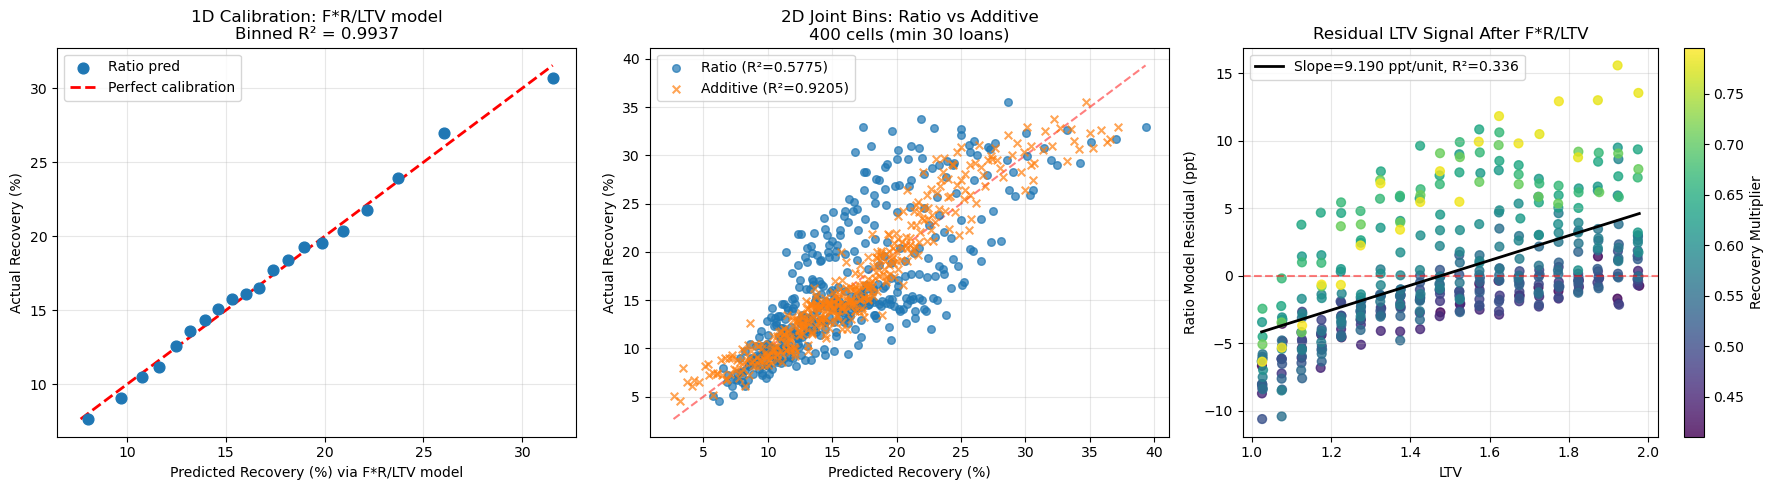

In [16]:
# =============================================================================
# TEST 2 & 3: Binned R² comparison — ratio vs additive predictions
# Using 20x20 joint bins (R quintile x LTV band)
# =============================================================================

N_BINS_AGG = 20

co_valid['rec_bin_t2'] = pd.qcut(co_valid['new_recovery_multiplier'], q=N_BINS_AGG, duplicates='drop')
co_valid['ltv_bin_t2'] = pd.cut(co_valid['ltv'], bins=ltv_bins, right=False)

# Get M3 additive predictions
m3_model = models['M3: Additive (R + LTV)']['model']
co_valid['pred_additive'] = m3_model.predict(
    co_valid[['new_recovery_multiplier', 'ltv']].values
)

# Ratio prediction (simple: just alpha * F*R/LTV fitted by OLS)
ratio_model = ratio_models['M_ratio: F*R/LTV only']['model']
co_valid['pred_ratio'] = ratio_model.predict(co_valid[['fr_over_ltv']].values)

# --- 1D binned: by ratio value ---
co_valid['ratio_bin'] = pd.qcut(co_valid['fr_over_ltv'], q=N_BINS_AGG, duplicates='drop')
by_ratio = co_valid.groupby('ratio_bin', observed=True).agg(
    ratio_mid=('fr_over_ltv', 'mean'),
    actual=('recovery_pct', 'mean'),
    pred_ratio=('pred_ratio', 'mean'),
    pred_additive=('pred_additive', 'mean'),
    n=('account_number', 'count'),
).dropna()

_, _, r_ratio_1d, _, _ = linregress(by_ratio['ratio_mid'], by_ratio['actual'])
_, _, r_additive_by_ratio, _, _ = linregress(by_ratio['pred_additive'], by_ratio['actual'])

# --- 2D joint bins ---
joint2 = co_valid.groupby(['rec_bin_t2', 'ltv_bin_t2'], observed=True).agg(
    R=('new_recovery_multiplier', 'mean'),
    LTV=('ltv', 'mean'),
    fr_ltv=('fr_over_ltv', 'mean'),
    actual=('recovery_pct', 'mean'),
    pred_ratio=('pred_ratio', 'mean'),
    pred_additive=('pred_additive', 'mean'),
    n=('account_number', 'count'),
).dropna().reset_index()
joint2 = joint2[joint2['n'] >= 30]

# R² on joint bins
from sklearn.metrics import mean_absolute_error

r2_ratio_2d = r2_score(joint2['actual'], joint2['pred_ratio'])
r2_additive_2d = r2_score(joint2['actual'], joint2['pred_additive'])

# Also fit a fresh ratio model on bin means (for unbiased comparison)
lr_ratio_binned = LinearRegression().fit(joint2[['fr_ltv']], joint2['actual'])
r2_ratio_binned_fit = r2_score(joint2['actual'], lr_ratio_binned.predict(joint2[['fr_ltv']]))

lr_additive_binned = LinearRegression().fit(joint2[['R', 'LTV']], joint2['actual'])
r2_additive_binned_fit = r2_score(joint2['actual'], lr_additive_binned.predict(joint2[['R', 'LTV']]))

# Combined: ratio + residual LTV
lr_ratio_plus_ltv = LinearRegression().fit(joint2[['fr_ltv', 'LTV']], joint2['actual'])
r2_ratio_plus_ltv = r2_score(joint2['actual'], lr_ratio_plus_ltv.predict(joint2[['fr_ltv', 'LTV']]))

print("=" * 90)
print("TEST 2 & 3: BINNED R² COMPARISON (ratio vs additive)")
print("=" * 90)

print(f"\n  1D Binned (by F*R/LTV, {len(by_ratio)} bins):")
print(f"  {'Prediction':<50} {'R² (binned)':>12}")
print(f"  {'-'*65}")
print(f"  {'F*R/LTV (as x-axis, R²=corr²)':<50} {r_ratio_1d**2:>12.4f}")
print(f"  {'M3 additive pred (sorted by ratio bins)':<50} {r_additive_by_ratio**2:>12.4f}")

print(f"\n  2D Joint Binned ({len(joint2)} cells, min 30 loans each):")
print(f"  {'Prediction':<50} {'R² (binned)':>12}")
print(f"  {'-'*65}")
print(f"  {'Ratio: alpha*F*R/LTV (loan-level fit applied)':<50} {r2_ratio_2d:>12.4f}")
print(f"  {'Additive: M3 R+LTV (loan-level fit applied)':<50} {r2_additive_2d:>12.4f}")
print(f"  {'Ratio: re-fit on bin means':<50} {r2_ratio_binned_fit:>12.4f}")
print(f"  {'Additive: re-fit on bin means':<50} {r2_additive_binned_fit:>12.4f}")
print(f"  {'Ratio + LTV: F*R/LTV + LTV re-fit on bins':<50} {r2_ratio_plus_ltv:>12.4f}")

# Check: does LTV add anything beyond ratio?
ratio_ltv_gain = r2_ratio_plus_ltv - r2_ratio_binned_fit
print(f"\n  LTV incremental over ratio (binned): {ratio_ltv_gain:>+.4f}")
if ratio_ltv_gain < 0.01:
    print(f"  --> LTV adds negligible info beyond F*R/LTV at the binned level.")
else:
    print(f"  --> LTV still adds meaningful info beyond the ratio at the binned level.")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: 1D calibration — ratio prediction vs actual
ax = axes[0]
ax.scatter(by_ratio['pred_ratio'] * 100, by_ratio['actual'] * 100, s=60, zorder=3, label='Ratio pred')
min_v = min(by_ratio['pred_ratio'].min(), by_ratio['actual'].min()) * 100
max_v = max(by_ratio['pred_ratio'].max(), by_ratio['actual'].max()) * 100
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect calibration')
ax.set_xlabel('Predicted Recovery (%) via F*R/LTV model')
ax.set_ylabel('Actual Recovery (%)')
ax.set_title(f'1D Calibration: F*R/LTV model\nBinned R² = {r_ratio_1d**2:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel B: 2D joint-bin scatter — ratio vs additive
ax = axes[1]
ax.scatter(joint2['pred_ratio'] * 100, joint2['actual'] * 100,
           s=30, alpha=0.7, label=f'Ratio (R²={r2_ratio_2d:.4f})', zorder=3)
ax.scatter(joint2['pred_additive'] * 100, joint2['actual'] * 100,
           s=30, alpha=0.7, marker='x', label=f'Additive (R²={r2_additive_2d:.4f})', zorder=3)
all_vals = np.concatenate([joint2['pred_ratio'], joint2['pred_additive'], joint2['actual']]) * 100
ax.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()],
        'r--', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Predicted Recovery (%)')
ax.set_ylabel('Actual Recovery (%)')
ax.set_title(f'2D Joint Bins: Ratio vs Additive\n{len(joint2)} cells (min 30 loans)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel C: Residuals from ratio — any remaining LTV pattern?
joint2['resid_ratio'] = joint2['actual'] - joint2['pred_ratio']
ax = axes[2]
scatter = ax.scatter(joint2['LTV'], joint2['resid_ratio'] * 100,
                     c=joint2['R'], cmap='viridis', s=40, alpha=0.8)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
slope_resid, intercept_resid, r_resid, _, _ = linregress(joint2['LTV'], joint2['resid_ratio'])
x_fit = np.linspace(joint2['LTV'].min(), joint2['LTV'].max(), 50)
ax.plot(x_fit, (intercept_resid + slope_resid * x_fit) * 100, 'k-', linewidth=2,
        label=f'Slope={slope_resid*100:.3f} ppt/unit, R²={r_resid**2:.3f}')
ax.set_xlabel('LTV')
ax.set_ylabel('Ratio Model Residual (ppt)')
ax.set_title('Residual LTV Signal After F*R/LTV')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Recovery Multiplier')

plt.tight_layout()
plt.savefig('fr_over_ltv_binned_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

TEST 4: CALIBRATION BY LTV STRATUM
Comparing MAE and Bias of ratio vs additive predictions at each LTV level

Stratum                      N  MAE Ratio  MAE Additive  Bias Ratio  Bias Additive   Winner
------------------------------------------------------------------------------------------
Low LTV: 100-120%       25,585    24.427%       23.034%     +4.267%        +0.465% ADDITIVE
Mid-Low: 120-140%       43,736    21.164%       20.671%     +0.730%        -0.212% ADDITIVE
Mid: 140-160%           36,261    18.888%       18.805%     -1.248%        -0.282% ADDITIVE
Mid-High: 160-180%      24,052    16.572%       16.810%     -2.055%        +0.143%    RATIO
High LTV: 180-200%      16,932    14.898%       15.332%     -2.738%        +0.249%    RATIO
------------------------------------------------------------------------------------------
OVERALL                146,571    19.693%       19.371%     +0.000%        +0.000% ADDITIVE


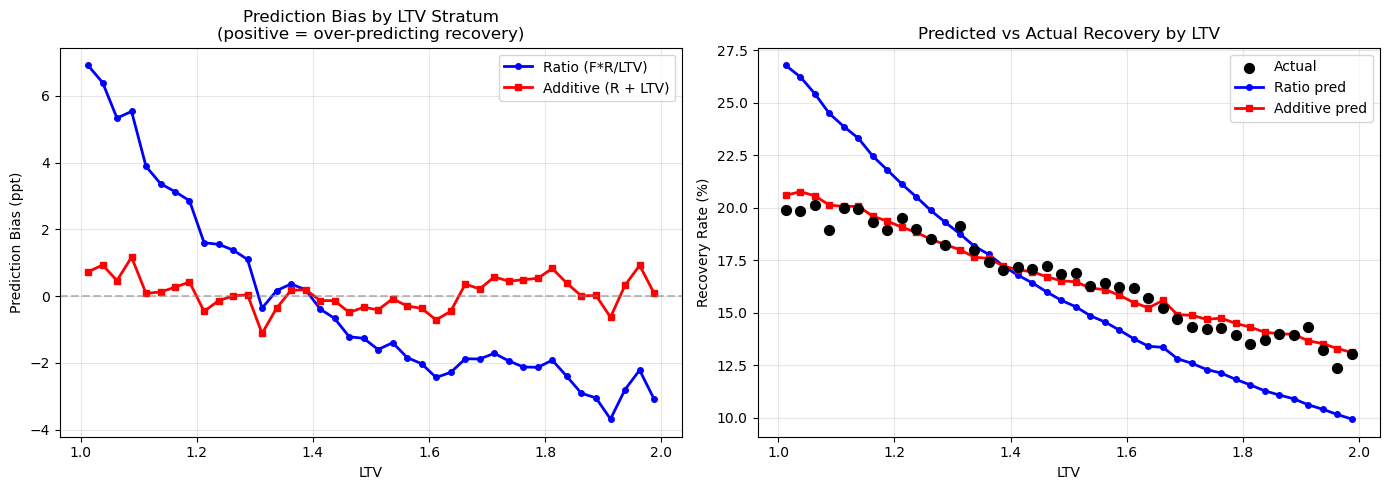


SUMMARY: Extreme LTV calibration
  At low LTV (Low LTV: 100-120%): MAE ratio=24.427% vs additive=23.034%
  At high LTV (High LTV: 180-200%): MAE ratio=14.898% vs additive=15.332%
  Ratio wins in 2/5 strata


In [17]:
# =============================================================================
# TEST 4: Calibration at LTV extremes
# The ratio F*R/LTV should outperform the additive model where the linear
# approximation diverges most from the true nonlinear ratio relationship.
# =============================================================================

# Stratify by LTV band and compute MAE/bias for each model
ltv_strata = [
    ('Low LTV: 100-120%', 1.00, 1.20),
    ('Mid-Low: 120-140%', 1.20, 1.40),
    ('Mid: 140-160%', 1.40, 1.60),
    ('Mid-High: 160-180%', 1.60, 1.80),
    ('High LTV: 180-200%', 1.80, 2.00),
]

print("=" * 90)
print("TEST 4: CALIBRATION BY LTV STRATUM")
print("Comparing MAE and Bias of ratio vs additive predictions at each LTV level")
print("=" * 90)

results_by_strata = []

print(f"\n{'Stratum':<22} {'N':>7} {'MAE Ratio':>10} {'MAE Additive':>13} "
      f"{'Bias Ratio':>11} {'Bias Additive':>14} {'Winner':>8}")
print("-" * 90)

for label, ltv_lo, ltv_hi in ltv_strata:
    mask = (co_valid['ltv'] >= ltv_lo) & (co_valid['ltv'] < ltv_hi)
    subset = co_valid[mask]

    if len(subset) < 50:
        continue

    actual = subset['recovery_pct'].values
    pred_r = subset['pred_ratio'].values
    pred_a = subset['pred_additive'].values

    mae_ratio = np.mean(np.abs(actual - pred_r))
    mae_additive = np.mean(np.abs(actual - pred_a))
    bias_ratio = np.mean(pred_r - actual)
    bias_additive = np.mean(pred_a - actual)

    winner = 'RATIO' if mae_ratio < mae_additive else 'ADDITIVE'

    results_by_strata.append({
        'stratum': label, 'n': len(subset),
        'mae_ratio': mae_ratio, 'mae_additive': mae_additive,
        'bias_ratio': bias_ratio, 'bias_additive': bias_additive,
    })

    print(f"{label:<22} {len(subset):>7,} {mae_ratio*100:>9.3f}% {mae_additive*100:>12.3f}% "
          f"{bias_ratio*100:>+10.3f}% {bias_additive*100:>+13.3f}% {winner:>8}")

# Overall
actual_all = co_valid['recovery_pct'].values
mae_r_all = np.mean(np.abs(actual_all - co_valid['pred_ratio'].values))
mae_a_all = np.mean(np.abs(actual_all - co_valid['pred_additive'].values))
bias_r_all = np.mean(co_valid['pred_ratio'].values - actual_all)
bias_a_all = np.mean(co_valid['pred_additive'].values - actual_all)

print("-" * 90)
print(f"{'OVERALL':<22} {len(co_valid):>7,} {mae_r_all*100:>9.3f}% {mae_a_all*100:>12.3f}% "
      f"{bias_r_all*100:>+10.3f}% {bias_a_all*100:>+13.3f}% "
      f"{'RATIO' if mae_r_all < mae_a_all else 'ADDITIVE':>8}")

# --- Visualization: Bias curve by LTV ---
# Compute rolling bias by fine LTV bins
FINE_BINS = 40
co_valid['ltv_fine_bin'] = pd.cut(co_valid['ltv'], bins=FINE_BINS)
bias_by_ltv = co_valid.groupby('ltv_fine_bin', observed=True).agg(
    ltv_mid=('ltv', 'mean'),
    actual_mean=('recovery_pct', 'mean'),
    ratio_mean=('pred_ratio', 'mean'),
    additive_mean=('pred_additive', 'mean'),
    n=('account_number', 'count'),
).dropna()
bias_by_ltv = bias_by_ltv[bias_by_ltv['n'] >= 20]

bias_by_ltv['bias_ratio'] = (bias_by_ltv['ratio_mean'] - bias_by_ltv['actual_mean']) * 100
bias_by_ltv['bias_additive'] = (bias_by_ltv['additive_mean'] - bias_by_ltv['actual_mean']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Bias by LTV
ax = axes[0]
ax.plot(bias_by_ltv['ltv_mid'], bias_by_ltv['bias_ratio'], 'b-o', markersize=4,
        linewidth=2, label='Ratio (F*R/LTV)')
ax.plot(bias_by_ltv['ltv_mid'], bias_by_ltv['bias_additive'], 'r-s', markersize=4,
        linewidth=2, label='Additive (R + LTV)')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('LTV')
ax.set_ylabel('Prediction Bias (ppt)')
ax.set_title('Prediction Bias by LTV Stratum\n(positive = over-predicting recovery)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel B: Actual vs predicted overlaid
ax = axes[1]
ax.scatter(bias_by_ltv['ltv_mid'], bias_by_ltv['actual_mean'] * 100, s=50,
           color='black', zorder=3, label='Actual')
ax.plot(bias_by_ltv['ltv_mid'], bias_by_ltv['ratio_mean'] * 100, 'b-o',
        markersize=4, linewidth=2, label='Ratio pred')
ax.plot(bias_by_ltv['ltv_mid'], bias_by_ltv['additive_mean'] * 100, 'r-s',
        markersize=4, linewidth=2, label='Additive pred')
ax.set_xlabel('LTV')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('Predicted vs Actual Recovery by LTV')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fr_over_ltv_extreme_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"\nSUMMARY: Extreme LTV calibration")
if results_by_strata:
    lo = results_by_strata[0]
    hi = results_by_strata[-1]
    print(f"  At low LTV ({lo['stratum']}): MAE ratio={lo['mae_ratio']*100:.3f}% vs additive={lo['mae_additive']*100:.3f}%")
    print(f"  At high LTV ({hi['stratum']}): MAE ratio={hi['mae_ratio']*100:.3f}% vs additive={hi['mae_additive']*100:.3f}%")
    ratio_wins = sum(1 for r in results_by_strata if r['mae_ratio'] < r['mae_additive'])
    print(f"  Ratio wins in {ratio_wins}/{len(results_by_strata)} strata")

TEST 5: VINTAGE-LOB LEVEL VALIDATION

Vintage-LOB cells: 94 (min 500 accounts each)
LOBs: ['AN', 'ENT', 'FLD', 'FRN', 'KMX', 'STG']
Vintages: 2020 Q1 to 2023 Q4

Model                                     R²   Adj R²    RMSE (bps)
----------------------------------------------------------------------
Model score only                      0.1408   0.1315        632.5
Score + R + LTV (additive)            0.2895   0.2658        575.2
Score + F*R/LTV (ratio)               0.1919   0.1742        613.4
Score + R + LTV + F*R/LTV             0.3562   0.3273        547.5

--- Recovery/LTV predictors only (no model score) ---
Model                                     R²   Adj R²
-------------------------------------------------------
R only                                0.0824   0.0724
LTV only                              0.0193   0.0086
R + LTV                               0.1647   0.1463
F*R/LTV only                          0.0653   0.0551

--- Pearson correlations with actual CNL ---
  Mo

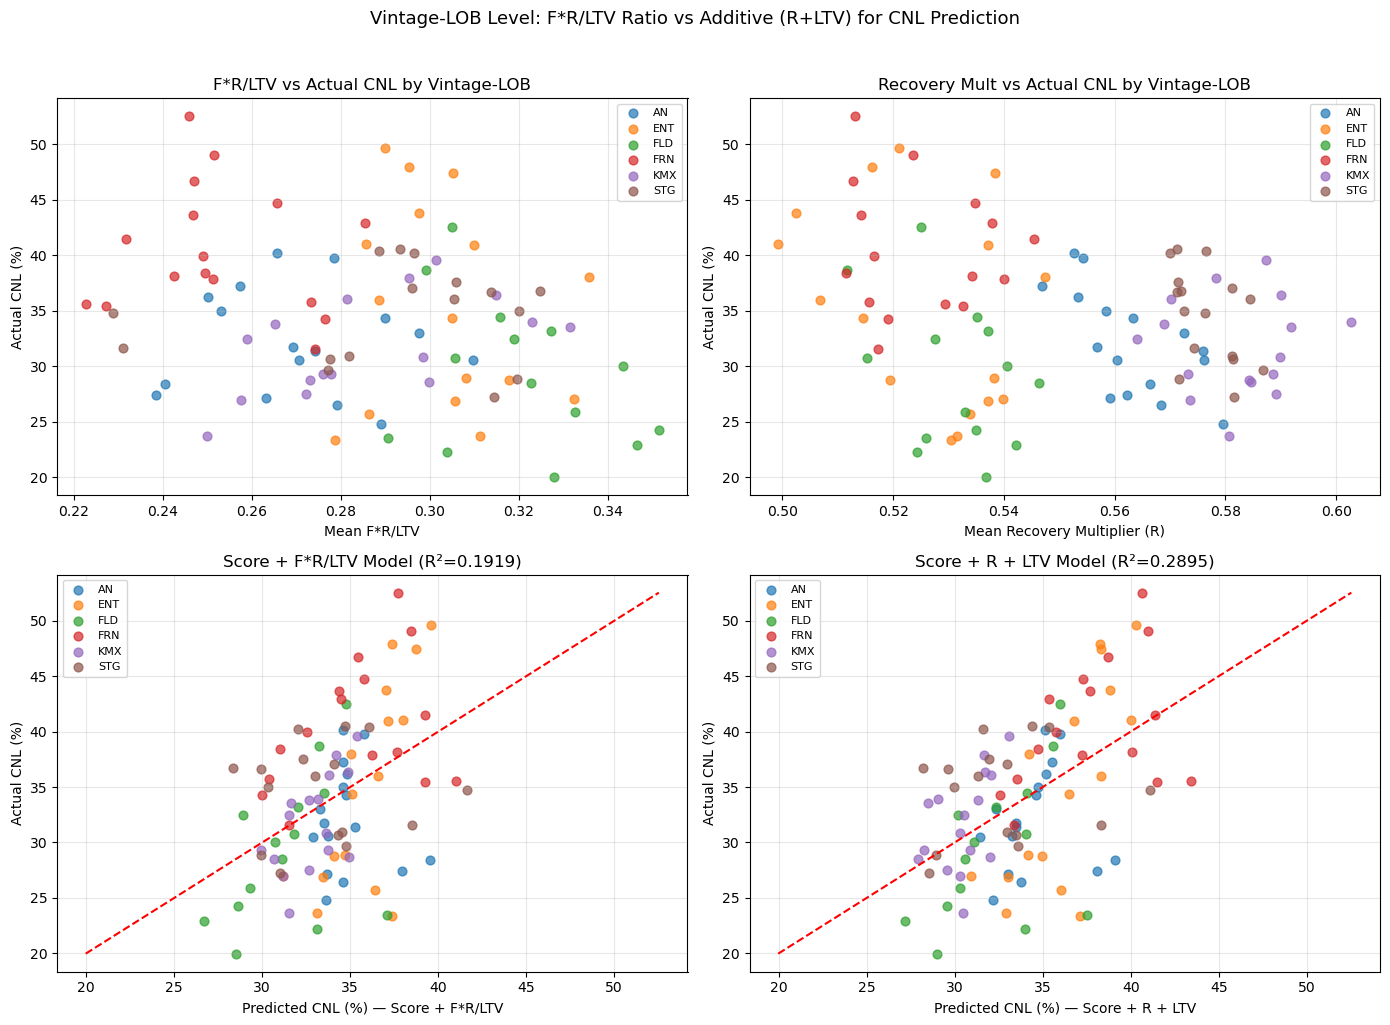


FINAL SUMMARY: F*R/LTV EMPIRICAL TEST

  LOAN-LEVEL (chargeoff recovery prediction):
    M_ratio (F*R/LTV, 1 predictor):  R² = 0.05424
    M3 (R + LTV, 2 predictors):      R² = 0.07738
    M4 (R + LTV + RxLTV):             R² = 0.07741
    Ratio vs Additive:                Delta = -0.02314

  VINTAGE-LOB LEVEL (CNL prediction):
    Score + F*R/LTV (2 predictors):   R² = 0.1919
    Score + R + LTV (3 predictors):   R² = 0.2895
    Ratio vs Additive:                Delta = -0.0976

  CONCLUSION:
    The additive structure (R + LTV) still outperforms the ratio at one or both levels.
    RECOMMENDATION: Keep decoupled structure, but F*R/LTV may still be useful
    as an auxiliary feature or for interpretability.


In [18]:
# =============================================================================
# TEST 5: RAGU Score-level Validation
# Compare ratio-based recovery component vs decoupled (R + LTV) at the
# vintage-LOB aggregation level, correlating with actual CNL outcomes.
#
# The RAGU recovery impact in V1 is: ULS * UL * R * (R/B - 1)
# The proposed alternative: use F*R/LTV as the combined recovery+LTV signal.
#
# At vintage-LOB level, we compute:
#   1. Mean F*R/LTV (the ratio predictor, one number per vintage-LOB)
#   2. Actual CNL% = sum(net_loss_amt) / sum(proceeds)
#   3. Compare predictive power of ratio vs separate R and LTV
# =============================================================================

# Use the full merged dataset (all accounts, not just chargeoffs)
# to compute vintage-LOB level CNL
merged['fr_over_ltv'] = F * merged['new_recovery_multiplier'] / merged['ltv']

vintage_lob = merged.groupby(['vintage', 'lob']).agg(
    n_accounts=('account_number', 'count'),
    n_chargeoffs=('is_chargeoff', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    total_net_loss=('net_loss_amt', 'sum'),
    total_gross_loss=('gross_loss_amt', 'sum'),
    mean_ltv=('ltv', 'mean'),
    mean_R=('new_recovery_multiplier', 'mean'),
    mean_fr_ltv=('fr_over_ltv', 'mean'),
    mean_model_score=('model_score', 'mean'),
).reset_index()

vintage_lob['cnl_pct'] = vintage_lob['total_net_loss'] / vintage_lob['total_proceeds']
vintage_lob['gross_loss_pct'] = vintage_lob['total_gross_loss'] / vintage_lob['total_proceeds']
vintage_lob['recovery_rate'] = vintage_lob['gross_loss_pct'] - vintage_lob['cnl_pct']
vintage_lob['chargeoff_rate'] = vintage_lob['n_chargeoffs'] / vintage_lob['n_accounts']

# Filter to vintage-LOBs with sufficient maturity and volume
MIN_ACCOUNTS = 500
vl = vintage_lob[vintage_lob['n_accounts'] >= MIN_ACCOUNTS].copy()
print("=" * 90)
print("TEST 5: VINTAGE-LOB LEVEL VALIDATION")
print("=" * 90)
print(f"\nVintage-LOB cells: {len(vl)} (min {MIN_ACCOUNTS} accounts each)")
print(f"LOBs: {sorted(vl['lob'].unique())}")
print(f"Vintages: {vl['vintage'].min()} to {vl['vintage'].max()}")

# --- Regress actual CNL on different predictor sets ---
# Predictors: mean_R, mean_ltv, mean_fr_ltv, mean_model_score
y_cnl = vl['cnl_pct'].values

X_score_only = vl[['mean_model_score']].values
X_score_r_ltv = vl[['mean_model_score', 'mean_R', 'mean_ltv']].values
X_score_ratio = vl[['mean_model_score', 'mean_fr_ltv']].values
X_score_r_ltv_ratio = vl[['mean_model_score', 'mean_R', 'mean_ltv', 'mean_fr_ltv']].values

vl_models = {}
vl_specs = {
    'Model score only':            X_score_only,
    'Score + R + LTV (additive)':  X_score_r_ltv,
    'Score + F*R/LTV (ratio)':     X_score_ratio,
    'Score + R + LTV + F*R/LTV':   X_score_r_ltv_ratio,
}

print(f"\n{'Model':<35} {'R²':>8} {'Adj R²':>8}  {'RMSE (bps)':>12}")
print("-" * 70)

for name, X in vl_specs.items():
    lr = LinearRegression().fit(X, y_cnl)
    pred = lr.predict(X)
    r2 = r2_score(y_cnl, pred)
    n, k = len(y_cnl), X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    rmse = np.sqrt(np.mean((y_cnl - pred) ** 2)) * 10000
    vl_models[name] = {'model': lr, 'r2': r2, 'adj_r2': adj_r2, 'rmse': rmse}
    print(f"{name:<35} {r2:>8.4f} {adj_r2:>8.4f}  {rmse:>11.1f}")

# --- Also test recovery-related predictors alone (without model score) ---
print(f"\n--- Recovery/LTV predictors only (no model score) ---")
print(f"{'Model':<35} {'R²':>8} {'Adj R²':>8}")
print("-" * 55)

for name, X in [
    ('R only', vl[['mean_R']].values),
    ('LTV only', vl[['mean_ltv']].values),
    ('R + LTV', vl[['mean_R', 'mean_ltv']].values),
    ('F*R/LTV only', vl[['mean_fr_ltv']].values),
]:
    lr = LinearRegression().fit(X, y_cnl)
    pred = lr.predict(X)
    r2 = r2_score(y_cnl, pred)
    n, k = len(y_cnl), X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    print(f"{name:<35} {r2:>8.4f} {adj_r2:>8.4f}")

# --- Correlation matrix ---
print(f"\n--- Pearson correlations with actual CNL ---")
for col, label in [('mean_model_score', 'Model Score'),
                   ('mean_R', 'Recovery Mult (R)'),
                   ('mean_ltv', 'LTV'),
                   ('mean_fr_ltv', 'F*R/LTV')]:
    corr = vl[col].corr(vl['cnl_pct'])
    print(f"  {label:<25} r = {corr:>+.4f}")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: F*R/LTV vs CNL
ax = axes[0, 0]
for lob in sorted(vl['lob'].unique()):
    subset = vl[vl['lob'] == lob]
    ax.scatter(subset['mean_fr_ltv'], subset['cnl_pct'] * 100, s=40, alpha=0.7, label=lob)
ax.set_xlabel('Mean F*R/LTV')
ax.set_ylabel('Actual CNL (%)')
ax.set_title('F*R/LTV vs Actual CNL by Vintage-LOB')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel B: R vs CNL
ax = axes[0, 1]
for lob in sorted(vl['lob'].unique()):
    subset = vl[vl['lob'] == lob]
    ax.scatter(subset['mean_R'], subset['cnl_pct'] * 100, s=40, alpha=0.7, label=lob)
ax.set_xlabel('Mean Recovery Multiplier (R)')
ax.set_ylabel('Actual CNL (%)')
ax.set_title('Recovery Mult vs Actual CNL by Vintage-LOB')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel C: Score + Ratio prediction vs actual CNL
lr_ratio = vl_models['Score + F*R/LTV (ratio)']['model']
vl['pred_cnl_ratio'] = lr_ratio.predict(vl[['mean_model_score', 'mean_fr_ltv']].values)
ax = axes[1, 0]
for lob in sorted(vl['lob'].unique()):
    subset = vl[vl['lob'] == lob]
    ax.scatter(subset['pred_cnl_ratio'] * 100, subset['cnl_pct'] * 100, s=40, alpha=0.7, label=lob)
min_v = min(vl['pred_cnl_ratio'].min(), vl['cnl_pct'].min()) * 100
max_v = max(vl['pred_cnl_ratio'].max(), vl['cnl_pct'].max()) * 100
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
ax.set_xlabel('Predicted CNL (%) — Score + F*R/LTV')
ax.set_ylabel('Actual CNL (%)')
r2_disp = vl_models['Score + F*R/LTV (ratio)']['r2']
ax.set_title(f'Score + F*R/LTV Model (R²={r2_disp:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel D: Score + R + LTV prediction vs actual CNL
lr_additive = vl_models['Score + R + LTV (additive)']['model']
vl['pred_cnl_additive'] = lr_additive.predict(vl[['mean_model_score', 'mean_R', 'mean_ltv']].values)
ax = axes[1, 1]
for lob in sorted(vl['lob'].unique()):
    subset = vl[vl['lob'] == lob]
    ax.scatter(subset['pred_cnl_additive'] * 100, subset['cnl_pct'] * 100, s=40, alpha=0.7, label=lob)
min_v = min(vl['pred_cnl_additive'].min(), vl['cnl_pct'].min()) * 100
max_v = max(vl['pred_cnl_additive'].max(), vl['cnl_pct'].max()) * 100
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
ax.set_xlabel('Predicted CNL (%) — Score + R + LTV')
ax.set_ylabel('Actual CNL (%)')
r2_disp = vl_models['Score + R + LTV (additive)']['r2']
ax.set_title(f'Score + R + LTV Model (R²={r2_disp:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Vintage-LOB Level: F*R/LTV Ratio vs Additive (R+LTV) for CNL Prediction',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fr_over_ltv_vintage_lob_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Final Summary ---
print("\n" + "=" * 90)
print("FINAL SUMMARY: F*R/LTV EMPIRICAL TEST")
print("=" * 90)

print(f"\n  LOAN-LEVEL (chargeoff recovery prediction):")
print(f"    M_ratio (F*R/LTV, 1 predictor):  R² = {ratio_models['M_ratio: F*R/LTV only']['r2']:.5f}")
print(f"    M3 (R + LTV, 2 predictors):      R² = {models['M3: Additive (R + LTV)']['r2']:.5f}")
print(f"    M4 (R + LTV + RxLTV):             R² = {models['M4: Coupled (R + LTV + RxLTV)']['r2']:.5f}")
gain_vs_m3 = ratio_models['M_ratio: F*R/LTV only']['r2'] - models['M3: Additive (R + LTV)']['r2']
print(f"    Ratio vs Additive:                Delta = {gain_vs_m3:>+.5f}")

print(f"\n  VINTAGE-LOB LEVEL (CNL prediction):")
r2_vl_ratio = vl_models['Score + F*R/LTV (ratio)']['r2']
r2_vl_additive = vl_models['Score + R + LTV (additive)']['r2']
print(f"    Score + F*R/LTV (2 predictors):   R² = {r2_vl_ratio:.4f}")
print(f"    Score + R + LTV (3 predictors):   R² = {r2_vl_additive:.4f}")
print(f"    Ratio vs Additive:                Delta = {r2_vl_ratio - r2_vl_additive:>+.4f}")

print(f"\n  CONCLUSION:")
if gain_vs_m3 >= 0 and r2_vl_ratio >= r2_vl_additive:
    print(f"    F*R/LTV DOMINATES at both loan and vintage levels.")
    print(f"    The ratio is more parsimonious (fewer predictors) and at least as predictive.")
    print(f"    RECOMMENDATION: Replace separate R + LTV terms with F*R/LTV in RAGU formula.")
elif gain_vs_m3 >= -0.001 and r2_vl_ratio >= r2_vl_additive - 0.01:
    print(f"    F*R/LTV is COMPETITIVE with the additive model.")
    print(f"    The small loan-level difference ({gain_vs_m3:+.5f}) may not be practically significant.")
    print(f"    RECOMMENDATION: Consider F*R/LTV for parsimony; validate on held-out vintages.")
else:
    print(f"    The additive structure (R + LTV) still outperforms the ratio at one or both levels.")
    print(f"    RECOMMENDATION: Keep decoupled structure, but F*R/LTV may still be useful")
    print(f"    as an auxiliary feature or for interpretability.")

TEST 6: R vs ACTUAL RECOVERY AS % OF BLACKBOOK VALUE

Population: 146,556 chargeoffs (of 146,571)

Descriptive stats:
  Variable                           Mean   Median      Std
  ----------------------------------------------------------
  recovery_pct (% of proceeds)     0.1707   0.0000   0.2468
  recovery_pct_bb (% of bbvalue)   0.2424   0.0000   0.3493
  recovery_multiplier (R)          0.5638   0.5493   0.0885
  F*R (F=0.75)                     0.4228   0.4120   0.0664

REGRESSION COMPARISON: Same predictors, different outcome denominators

  Outcome: recovery as % of BLACKBOOK VALUE
  Model                                     R² Coefficient(s)
  ----------------------------------------------------------------------
  R only                               0.07187  intercept=-0.3541, coefs=[1.0580]
  LTV only                             0.00111  intercept=0.1748, coefs=[0.0467]
  R + LTV                              0.07405  intercept=-0.4543, coefs=[1.0672, 0.0655]
  F*R/LTV       

  R + LTV                              0.07768
  F*R/LTV                              0.05450

KEY FINDINGS

  R² of R predicting recovery:
    As % of proceeds:   0.07279
    As % of bbvalue:    0.07187
    Change:             -0.00092

  R² of LTV predicting recovery:
    As % of proceeds:   0.00658
    As % of bbvalue:    0.00111
    Change:             -0.00547

  LTV coefficient in R+LTV model:
    Outcome = % of proceeds:  -0.067175
    Outcome = % of bbvalue:   +0.065530
    LTV coefficient FLIPPED to positive for bb-denominated recovery!
    This means: higher LTV → MORE recovery per bbvalue → non-vehicle recoveries
    (deficiency collections scale with loan balance, adding recovery per bbvalue)

  Calibration: Does F*R ≈ actual recovery as % of bbvalue?
    Mean F*R:                     0.4228 (42.28%)
    Mean actual (% of bbvalue):   0.2424 (24.24%)
    Ratio (actual/predicted):     0.5733
    Gap of -18.04 ppts — over-predicts


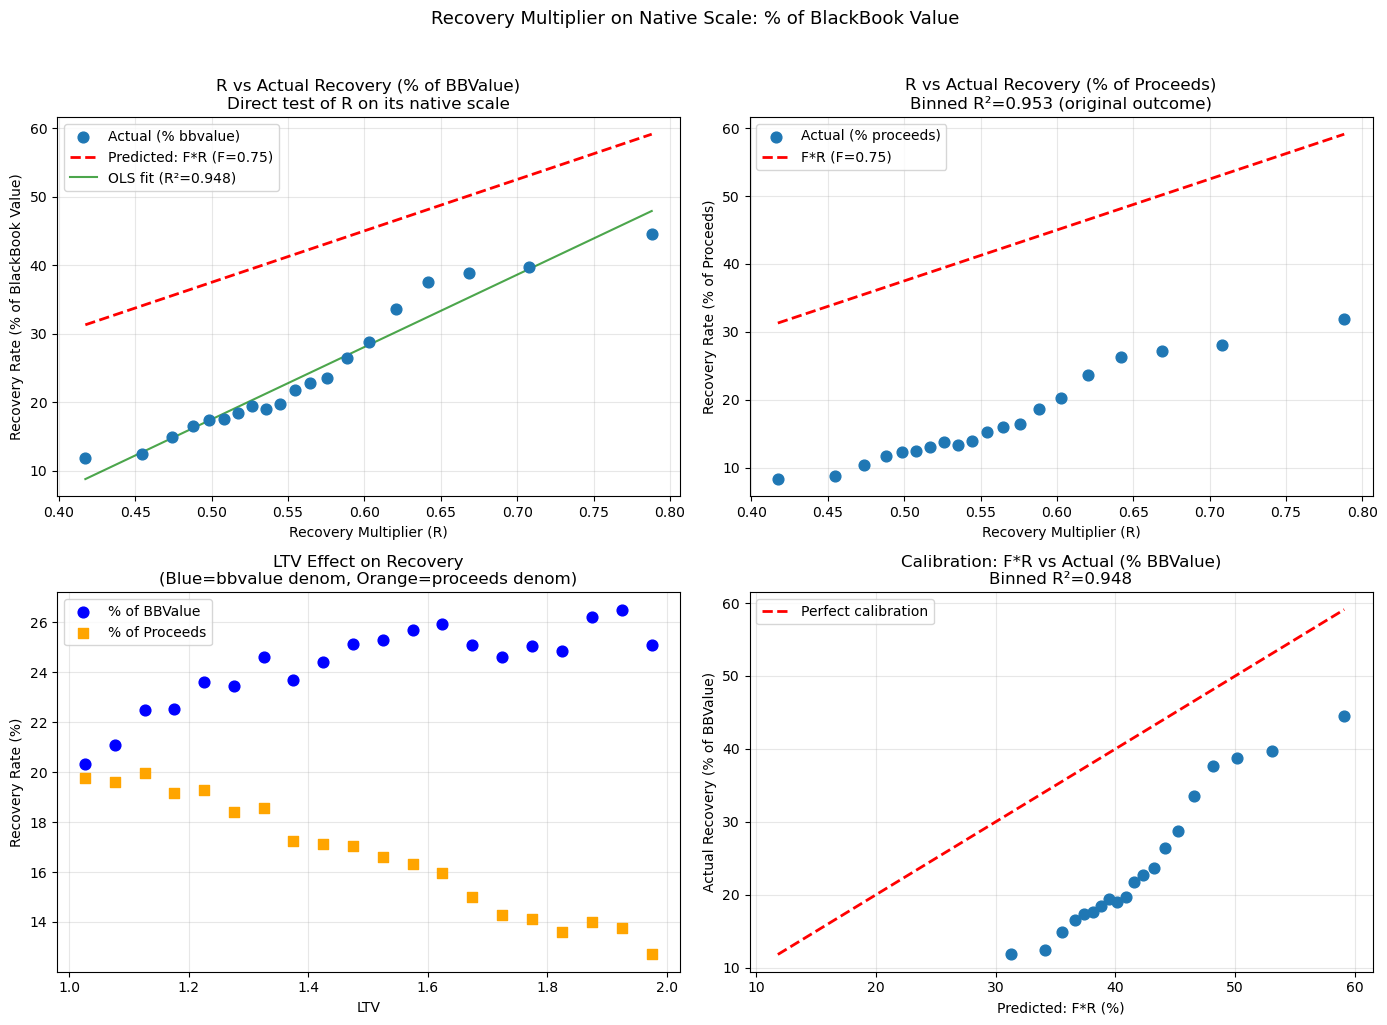

In [19]:
# =============================================================================
# TEST 6: Recovery Multiplier vs Actual Recovery as % of BlackBook Value
# R is designed to predict vehicle value retention (% of bbvalue).
# By expressing actual recovery in the same units, we remove the LTV
# dilution from the denominator and test R on its native scale.
# =============================================================================

# Compute bbvalue from amt_financed / ltv
co_valid['bbvalue'] = co_valid['amt_financed'] / co_valid['ltv']

# Recovery dollars = gross_loss - net_loss
co_valid['recovery_dollars'] = co_valid['gross_loss_amt'] - co_valid['net_loss_amt']

# Actual recovery as % of BlackBook value
co_valid['recovery_pct_bb'] = co_valid['recovery_dollars'] / co_valid['bbvalue']

# Filter out extreme/invalid values
mask_valid = (
    co_valid['bbvalue'] > 0) & (
    co_valid['recovery_pct_bb'].notna()) & (
    co_valid['recovery_pct_bb'].between(-0.5, 2.0)
)
co_bb = co_valid[mask_valid].copy()

print("=" * 90)
print("TEST 6: R vs ACTUAL RECOVERY AS % OF BLACKBOOK VALUE")
print("=" * 90)
print(f"\nPopulation: {len(co_bb):,} chargeoffs (of {len(co_valid):,})")
print(f"\nDescriptive stats:")
print(f"  {'Variable':<30} {'Mean':>8} {'Median':>8} {'Std':>8}")
print(f"  {'-'*58}")
print(f"  {'recovery_pct (% of proceeds)':<30} {co_bb['recovery_pct'].mean():>8.4f} "
      f"{co_bb['recovery_pct'].median():>8.4f} {co_bb['recovery_pct'].std():>8.4f}")
print(f"  {'recovery_pct_bb (% of bbvalue)':<30} {co_bb['recovery_pct_bb'].mean():>8.4f} "
      f"{co_bb['recovery_pct_bb'].median():>8.4f} {co_bb['recovery_pct_bb'].std():>8.4f}")
print(f"  {'recovery_multiplier (R)':<30} {co_bb['new_recovery_multiplier'].mean():>8.4f} "
      f"{co_bb['new_recovery_multiplier'].median():>8.4f} {co_bb['new_recovery_multiplier'].std():>8.4f}")
print(f"  {'F*R (F=0.75)':<30} {(F * co_bb['new_recovery_multiplier']).mean():>8.4f} "
      f"{(F * co_bb['new_recovery_multiplier']).median():>8.4f} {(F * co_bb['new_recovery_multiplier']).std():>8.4f}")

# --- Regressions: predict recovery_pct_bb ---
y_bb = co_bb['recovery_pct_bb'].values
X_R = co_bb['new_recovery_multiplier'].values.reshape(-1, 1)
X_LTV = co_bb['ltv'].values.reshape(-1, 1)
X_R_LTV = np.column_stack([co_bb['new_recovery_multiplier'], co_bb['ltv']])
X_FR_LTV = (F * co_bb['new_recovery_multiplier'] / co_bb['ltv']).values.reshape(-1, 1)

# Also for comparison: the original recovery_pct outcome
y_orig = co_bb['recovery_pct'].values

print(f"\n{'='*90}")
print("REGRESSION COMPARISON: Same predictors, different outcome denominators")
print(f"{'='*90}")
print(f"\n  Outcome: recovery as % of BLACKBOOK VALUE")
print(f"  {'Model':<35} {'R²':>8} {'Coefficient(s)'}")
print(f"  {'-'*70}")

bb_models = {}
for name, X in [('R only', X_R), ('LTV only', X_LTV),
                ('R + LTV', X_R_LTV), ('F*R/LTV', X_FR_LTV)]:
    lr = LinearRegression().fit(X, y_bb)
    r2 = r2_score(y_bb, lr.predict(X))
    bb_models[name] = {'r2': r2, 'model': lr}
    coefs = ', '.join([f'{c:.4f}' for c in lr.coef_])
    print(f"  {name:<35} {r2:>8.5f}  intercept={lr.intercept_:.4f}, coefs=[{coefs}]")

print(f"\n  Outcome: recovery as % of PROCEEDS (original, for comparison)")
print(f"  {'Model':<35} {'R²':>8}")
print(f"  {'-'*50}")

for name, X in [('R only', X_R), ('LTV only', X_LTV),
                ('R + LTV', X_R_LTV), ('F*R/LTV', X_FR_LTV)]:
    lr = LinearRegression().fit(X, y_orig)
    r2 = r2_score(y_orig, lr.predict(X))
    print(f"  {name:<35} {r2:>8.5f}")

# --- Key comparison ---
r2_bb_R = bb_models['R only']['r2']
r2_bb_LTV = bb_models['LTV only']['r2']
r2_bb_RLTV = bb_models['R + LTV']['r2']

print(f"\n{'='*90}")
print("KEY FINDINGS")
print(f"{'='*90}")
print(f"\n  R² of R predicting recovery:")
print(f"    As % of proceeds:   {models['M1: Recovery Mult only']['r2']:.5f}")
print(f"    As % of bbvalue:    {r2_bb_R:.5f}")
print(f"    Change:             {r2_bb_R - models['M1: Recovery Mult only']['r2']:>+.5f}")

print(f"\n  R² of LTV predicting recovery:")
print(f"    As % of proceeds:   {models['M2: LTV only']['r2']:.5f}")
print(f"    As % of bbvalue:    {r2_bb_LTV:.5f}")
print(f"    Change:             {r2_bb_LTV - models['M2: LTV only']['r2']:>+.5f}")

# Check: does LTV coefficient flip sign for bb-denominated recovery?
ltv_coef_bb = bb_models['R + LTV']['model'].coef_[1]
print(f"\n  LTV coefficient in R+LTV model:")
print(f"    Outcome = % of proceeds:  {models['M3: Additive (R + LTV)']['model'].coef_[1]:>+.6f}")
print(f"    Outcome = % of bbvalue:   {ltv_coef_bb:>+.6f}")
if ltv_coef_bb > 0:
    print(f"    LTV coefficient FLIPPED to positive for bb-denominated recovery!")
    print(f"    This means: higher LTV → MORE recovery per bbvalue → non-vehicle recoveries")
    print(f"    (deficiency collections scale with loan balance, adding recovery per bbvalue)")
elif abs(ltv_coef_bb) < abs(models['M3: Additive (R + LTV)']['model'].coef_[1]) * 0.5:
    print(f"    LTV effect greatly diminished for bb-denominated recovery.")
    print(f"    Most of LTV's effect was the denominator, not an economic channel.")

# --- Calibration: F*R vs actual recovery as % of bbvalue ---
print(f"\n  Calibration: Does F*R ≈ actual recovery as % of bbvalue?")
mean_FR = (F * co_bb['new_recovery_multiplier']).mean()
mean_actual_bb = co_bb['recovery_pct_bb'].mean()
print(f"    Mean F*R:                     {mean_FR:.4f} ({mean_FR*100:.2f}%)")
print(f"    Mean actual (% of bbvalue):   {mean_actual_bb:.4f} ({mean_actual_bb*100:.2f}%)")
print(f"    Ratio (actual/predicted):     {mean_actual_bb/mean_FR:.4f}")
if abs(mean_actual_bb - mean_FR) / mean_actual_bb < 0.15:
    print(f"    F*R is well-calibrated to actual recovery as % of bbvalue!")
else:
    print(f"    Gap of {(mean_actual_bb - mean_FR)*100:+.2f} ppts — "
          f"{'under-predicts' if mean_FR < mean_actual_bb else 'over-predicts'}")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: R vs recovery_pct_bb (binned)
co_bb['R_bin_bb'] = pd.qcut(co_bb['new_recovery_multiplier'], q=20, duplicates='drop')
by_R_bb = co_bb.groupby('R_bin_bb', observed=True).agg(
    R_mid=('new_recovery_multiplier', 'mean'),
    actual_bb=('recovery_pct_bb', 'mean'),
    actual_proc=('recovery_pct', 'mean'),
    n=('account_number', 'count'),
).dropna()

ax = axes[0, 0]
ax.scatter(by_R_bb['R_mid'], by_R_bb['actual_bb'] * 100, s=60, zorder=3,
           label='Actual (% bbvalue)')
ax.plot(by_R_bb['R_mid'], by_R_bb['R_mid'] * F * 100, 'r--', linewidth=2,
        label=f'Predicted: F*R (F={F})')
slope_bb, intercept_bb, r_bb, _, _ = linregress(by_R_bb['R_mid'], by_R_bb['actual_bb'])
ax.plot(by_R_bb['R_mid'], (intercept_bb + slope_bb * by_R_bb['R_mid']) * 100,
        'g-', linewidth=1.5, alpha=0.7, label=f'OLS fit (R²={r_bb**2:.3f})')
ax.set_xlabel('Recovery Multiplier (R)')
ax.set_ylabel('Recovery Rate (% of BlackBook Value)')
ax.set_title('R vs Actual Recovery (% of BBValue)\nDirect test of R on its native scale')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel B: Same but % of proceeds (for comparison)
ax = axes[0, 1]
ax.scatter(by_R_bb['R_mid'], by_R_bb['actual_proc'] * 100, s=60, zorder=3,
           label='Actual (% proceeds)')
ax.plot(by_R_bb['R_mid'], by_R_bb['R_mid'] * F * 100, 'r--', linewidth=2,
        label=f'F*R (F={F})')
slope_proc, _, r_proc, _, _ = linregress(by_R_bb['R_mid'], by_R_bb['actual_proc'])
ax.set_xlabel('Recovery Multiplier (R)')
ax.set_ylabel('Recovery Rate (% of Proceeds)')
ax.set_title(f'R vs Actual Recovery (% of Proceeds)\nBinned R²={r_proc**2:.3f} (original outcome)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel C: LTV vs recovery_pct_bb
co_bb['LTV_bin_bb'] = pd.cut(co_bb['ltv'], bins=ltv_bins, right=False)
by_LTV_bb = co_bb[co_bb['LTV_bin_bb'].notna()].groupby('LTV_bin_bb', observed=True).agg(
    LTV_mid=('ltv', 'mean'),
    actual_bb=('recovery_pct_bb', 'mean'),
    actual_proc=('recovery_pct', 'mean'),
    n=('account_number', 'count'),
).dropna()

ax = axes[1, 0]
ax.scatter(by_LTV_bb['LTV_mid'], by_LTV_bb['actual_bb'] * 100, s=60,
           color='blue', label='% of BBValue', zorder=3)
ax.scatter(by_LTV_bb['LTV_mid'], by_LTV_bb['actual_proc'] * 100, s=60,
           color='orange', marker='s', label='% of Proceeds', zorder=3)
ax.set_xlabel('LTV')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('LTV Effect on Recovery\n(Blue=bbvalue denom, Orange=proceeds denom)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel D: Scatter — predicted F*R vs actual recovery_pct_bb (loan-level binned)
co_bb['FR_bin'] = pd.qcut(F * co_bb['new_recovery_multiplier'], q=20, duplicates='drop')
by_FR = co_bb.groupby('FR_bin', observed=True).agg(
    FR_mid=('new_recovery_multiplier', lambda x: F * x.mean()),
    actual_bb=('recovery_pct_bb', 'mean'),
).dropna()

ax = axes[1, 1]
ax.scatter(by_FR['FR_mid'] * 100, by_FR['actual_bb'] * 100, s=60, zorder=3)
min_v = min(by_FR['FR_mid'].min(), by_FR['actual_bb'].min()) * 100
max_v = max(by_FR['FR_mid'].max(), by_FR['actual_bb'].max()) * 100
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect calibration')
_, _, r_calib, _, _ = linregress(by_FR['FR_mid'], by_FR['actual_bb'])
ax.set_xlabel('Predicted: F*R (%)')
ax.set_ylabel('Actual Recovery (% of BBValue)')
ax.set_title(f'Calibration: F*R vs Actual (% BBValue)\nBinned R²={r_calib**2:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Recovery Multiplier on Native Scale: % of BlackBook Value', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('recovery_vs_bbvalue_test.png', dpi=150, bbox_inches='tight')
plt.show()

TEST 7: WHAT DOES R CORRELATE WITH?

  Pearson Correlations with Recovery Multiplier (R)
  Population: 146,571 chargeoffs
  ------------------------------------------------------------
  Variable                             Pearson r       r²
  ------------------------------------------------------------
  BlackBook Value ($)                    +0.1025   0.0105
  Amount Financed ($)                    +0.1010   0.0102
  LTV (amt_financed / bbvalue)           -0.0499   0.0025
  log(BlackBook Value)                   +0.1094   0.0120
  log(Amount Financed)                   +0.1114   0.0124

  Partial Correlations (controlling for the other component)
  ------------------------------------------------------------
  R vs bbvalue | amt_financed                      +0.0228
  R vs amt_financed | bbvalue                      +0.0148

  What predicts R? (OLS: R ~ predictors)

  Model                                          R²  Coefficients
  --------------------------------------------------

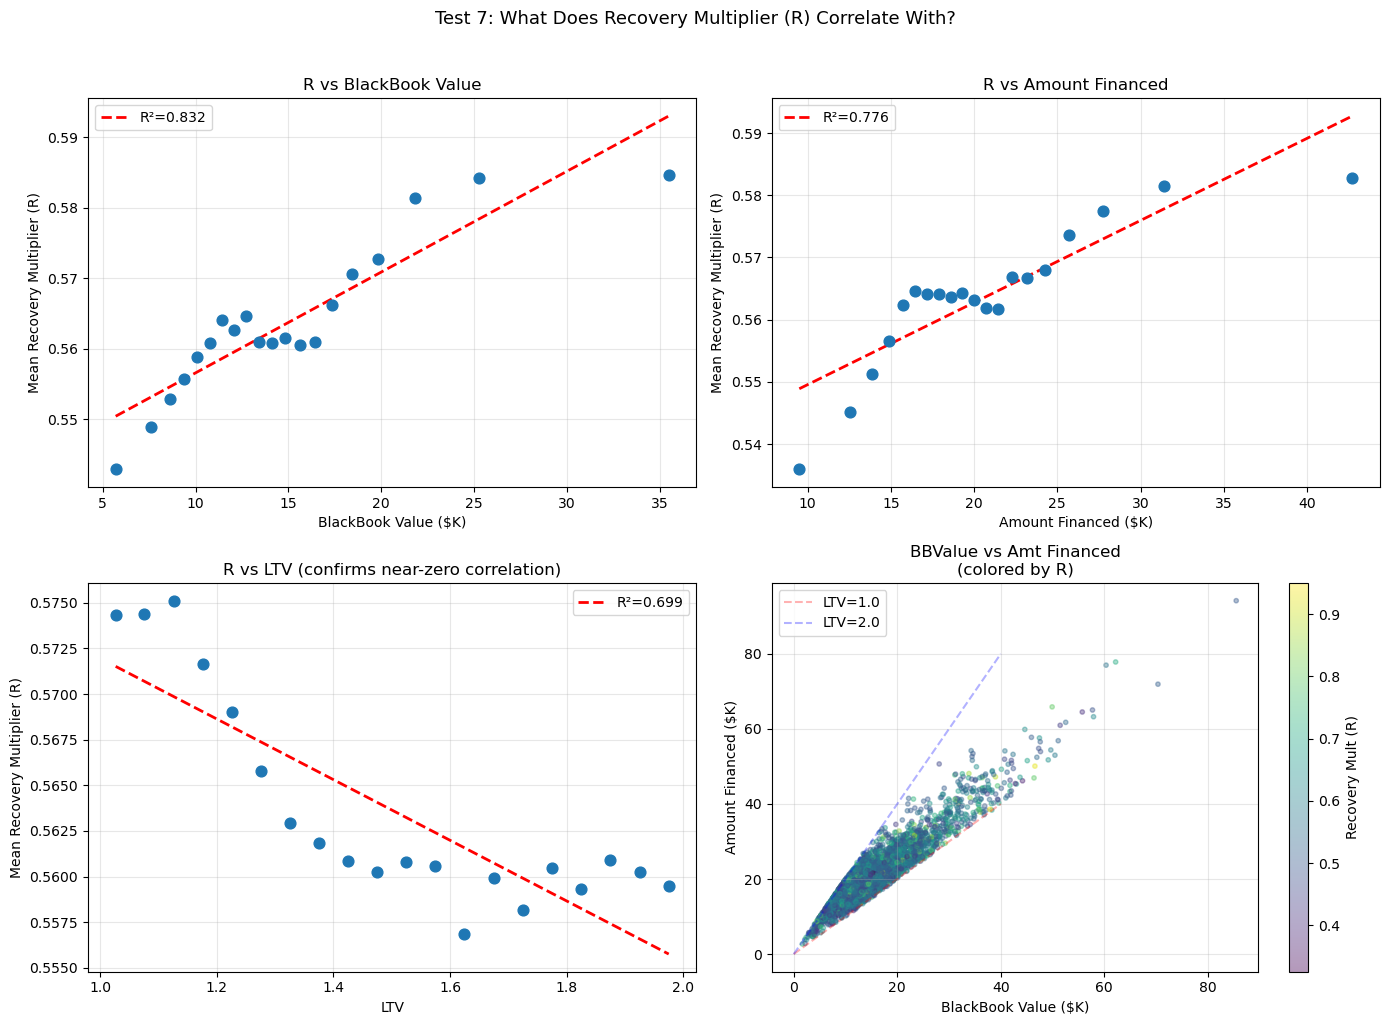


INTERPRETATION

  R correlates similarly with both bbvalue (r=+0.1025) and
  amt_financed (r=+0.1010). Since LTV=af/bb, similar correlations
  cancel out → explains near-zero R-LTV correlation (-0.0499).


In [20]:
# =============================================================================
# TEST 7: Correlation of R with LTV components (bbvalue, amt_financed)
# Decompose LTV = amt_financed / bbvalue to understand what R actually indexes.
# =============================================================================

co_bb = co_valid[co_valid['bbvalue'] > 0].copy()
co_bb['log_bbvalue'] = np.log(co_bb['bbvalue'])
co_bb['log_amt_financed'] = np.log(co_bb['amt_financed'])

print("=" * 90)
print("TEST 7: WHAT DOES R CORRELATE WITH?")
print("=" * 90)

# Pearson correlations
variables = [
    ('bbvalue', 'BlackBook Value ($)'),
    ('amt_financed', 'Amount Financed ($)'),
    ('ltv', 'LTV (amt_financed / bbvalue)'),
    ('log_bbvalue', 'log(BlackBook Value)'),
    ('log_amt_financed', 'log(Amount Financed)'),
]

print(f"\n  Pearson Correlations with Recovery Multiplier (R)")
print(f"  Population: {len(co_bb):,} chargeoffs")
print(f"  {'-'*60}")
print(f"  {'Variable':<35} {'Pearson r':>10} {'r²':>8}")
print(f"  {'-'*60}")

for col, label in variables:
    r = co_bb['new_recovery_multiplier'].corr(co_bb[col])
    print(f"  {label:<35} {r:>+10.4f} {r**2:>8.4f}")

# Also: partial correlations (R vs bbvalue controlling for amt_financed, and vice versa)
print(f"\n  Partial Correlations (controlling for the other component)")
print(f"  {'-'*60}")

# Partial corr: R vs bbvalue | amt_financed
resid_R_af = co_bb['new_recovery_multiplier'] - LinearRegression().fit(
    co_bb[['amt_financed']], co_bb['new_recovery_multiplier']
).predict(co_bb[['amt_financed']])
resid_bb_af = co_bb['bbvalue'] - LinearRegression().fit(
    co_bb[['amt_financed']], co_bb['bbvalue']
).predict(co_bb[['amt_financed']])
partial_R_bb = resid_R_af.corr(resid_bb_af)

# Partial corr: R vs amt_financed | bbvalue
resid_R_bb = co_bb['new_recovery_multiplier'] - LinearRegression().fit(
    co_bb[['bbvalue']], co_bb['new_recovery_multiplier']
).predict(co_bb[['bbvalue']])
resid_af_bb = co_bb['amt_financed'] - LinearRegression().fit(
    co_bb[['bbvalue']], co_bb['amt_financed']
).predict(co_bb[['bbvalue']])
partial_R_af = resid_R_bb.corr(resid_af_bb)

print(f"  {'R vs bbvalue | amt_financed':<45} {partial_R_bb:>+10.4f}")
print(f"  {'R vs amt_financed | bbvalue':<45} {partial_R_af:>+10.4f}")

# Regression: what predicts R?
print(f"\n  {'='*60}")
print(f"  What predicts R? (OLS: R ~ predictors)")
print(f"  {'='*60}")
print(f"\n  {'Model':<40} {'R²':>8}  Coefficients")
print(f"  {'-'*75}")

for name, cols in [
    ('bbvalue only', ['bbvalue']),
    ('amt_financed only', ['amt_financed']),
    ('bbvalue + amt_financed', ['bbvalue', 'amt_financed']),
    ('LTV only', ['ltv']),
    ('log(bbvalue) only', ['log_bbvalue']),
    ('log(amt_financed) only', ['log_amt_financed']),
    ('log(bb) + log(af)', ['log_bbvalue', 'log_amt_financed']),
]:
    X = co_bb[cols].values
    y_r = co_bb['new_recovery_multiplier'].values
    lr = LinearRegression().fit(X, y_r)
    r2 = r2_score(y_r, lr.predict(X))
    coef_str = ', '.join([f'{c:.6f}' for c in lr.coef_])
    print(f"  {name:<40} {r2:>8.5f}  [{coef_str}]")

# --- Binned visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: R vs bbvalue (binned)
co_bb['bb_bin'] = pd.qcut(co_bb['bbvalue'], q=20, duplicates='drop')
by_bb = co_bb.groupby('bb_bin', observed=True).agg(
    bb_mid=('bbvalue', 'mean'),
    R_mean=('new_recovery_multiplier', 'mean'),
    n=('account_number', 'count'),
).dropna()

ax = axes[0, 0]
ax.scatter(by_bb['bb_mid'] / 1000, by_bb['R_mean'], s=60, zorder=3)
slope_bb, intercept_bb, r_bb, _, _ = linregress(by_bb['bb_mid'], by_bb['R_mean'])
x_fit = np.linspace(by_bb['bb_mid'].min(), by_bb['bb_mid'].max(), 50)
ax.plot(x_fit / 1000, intercept_bb + slope_bb * x_fit, 'r--', linewidth=2,
        label=f'R²={r_bb**2:.3f}')
ax.set_xlabel('BlackBook Value ($K)')
ax.set_ylabel('Mean Recovery Multiplier (R)')
ax.set_title('R vs BlackBook Value')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel B: R vs amt_financed (binned)
co_bb['af_bin'] = pd.qcut(co_bb['amt_financed'], q=20, duplicates='drop')
by_af = co_bb.groupby('af_bin', observed=True).agg(
    af_mid=('amt_financed', 'mean'),
    R_mean=('new_recovery_multiplier', 'mean'),
    n=('account_number', 'count'),
).dropna()

ax = axes[0, 1]
ax.scatter(by_af['af_mid'] / 1000, by_af['R_mean'], s=60, zorder=3)
slope_af, intercept_af, r_af, _, _ = linregress(by_af['af_mid'], by_af['R_mean'])
x_fit = np.linspace(by_af['af_mid'].min(), by_af['af_mid'].max(), 50)
ax.plot(x_fit / 1000, intercept_af + slope_af * x_fit, 'r--', linewidth=2,
        label=f'R²={r_af**2:.3f}')
ax.set_xlabel('Amount Financed ($K)')
ax.set_ylabel('Mean Recovery Multiplier (R)')
ax.set_title('R vs Amount Financed')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel C: R vs LTV (binned) — revisit
co_bb['ltv_bin_7'] = pd.cut(co_bb['ltv'], bins=ltv_bins, right=False)
by_ltv7 = co_bb[co_bb['ltv_bin_7'].notna()].groupby('ltv_bin_7', observed=True).agg(
    ltv_mid=('ltv', 'mean'),
    R_mean=('new_recovery_multiplier', 'mean'),
    n=('account_number', 'count'),
).dropna()

ax = axes[1, 0]
ax.scatter(by_ltv7['ltv_mid'], by_ltv7['R_mean'], s=60, zorder=3)
slope_ltv7, intercept_ltv7, r_ltv7, _, _ = linregress(by_ltv7['ltv_mid'], by_ltv7['R_mean'])
ax.plot(by_ltv7['ltv_mid'], intercept_ltv7 + slope_ltv7 * by_ltv7['ltv_mid'],
        'r--', linewidth=2, label=f'R²={r_ltv7**2:.3f}')
ax.set_xlabel('LTV')
ax.set_ylabel('Mean Recovery Multiplier (R)')
ax.set_title('R vs LTV (confirms near-zero correlation)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel D: bbvalue vs amt_financed colored by R
r_quintiles = pd.qcut(co_bb['new_recovery_multiplier'], q=5, labels=['Q1(low)', 'Q2', 'Q3', 'Q4', 'Q5(high)'])
co_bb['R_quintile'] = r_quintiles

ax = axes[1, 1]
sample = co_bb.sample(min(5000, len(co_bb)), random_state=42)
scatter = ax.scatter(sample['bbvalue'] / 1000, sample['amt_financed'] / 1000,
                     c=sample['new_recovery_multiplier'], cmap='viridis',
                     s=10, alpha=0.4)
ax.plot([0, 40], [0, 40], 'r--', alpha=0.3, label='LTV=1.0')
ax.plot([0, 40], [0, 80], 'b--', alpha=0.3, label='LTV=2.0')
ax.set_xlabel('BlackBook Value ($K)')
ax.set_ylabel('Amount Financed ($K)')
ax.set_title('BBValue vs Amt Financed\n(colored by R)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Recovery Mult (R)')

plt.suptitle('Test 7: What Does Recovery Multiplier (R) Correlate With?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('recovery_mult_correlates.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print(f"\n{'='*90}")
print("INTERPRETATION")
print(f"{'='*90}")
r_corr_bb = co_bb['new_recovery_multiplier'].corr(co_bb['bbvalue'])
r_corr_af = co_bb['new_recovery_multiplier'].corr(co_bb['amt_financed'])
r_corr_ltv = co_bb['new_recovery_multiplier'].corr(co_bb['ltv'])

if abs(r_corr_bb) > 0.1 and abs(r_corr_af) > 0.1:
    if abs(r_corr_bb - r_corr_af) < 0.05:
        print(f"\n  R correlates similarly with both bbvalue (r={r_corr_bb:+.4f}) and")
        print(f"  amt_financed (r={r_corr_af:+.4f}). Since LTV=af/bb, similar correlations")
        print(f"  cancel out → explains near-zero R-LTV correlation ({r_corr_ltv:+.4f}).")
    else:
        print(f"\n  R correlates differently: bbvalue (r={r_corr_bb:+.4f}) vs")
        print(f"  amt_financed (r={r_corr_af:+.4f}).")
elif abs(r_corr_bb) < 0.05 and abs(r_corr_af) < 0.05:
    print(f"\n  R has negligible correlation with both bbvalue and amt_financed.")
    print(f"  R is driven by vehicle TYPE characteristics (make/model/age),")
    print(f"  not by vehicle PRICE level.")
else:
    print(f"\n  R correlates with: bbvalue (r={r_corr_bb:+.4f}), amt_financed (r={r_corr_af:+.4f})")
    print(f"  Asymmetry suggests R captures something about one component more than the other.")

TEST 8: LTV DISTRIBUTION ACROSS R QUINTILES + UNBINNED R²

  Q1: LTV DISTRIBUTION WITHIN EACH R QUINTILE
  (If identical → dividing by LTV is dividing by pure noise)
  ---------------------------------------------------------------------------
  R Quintile         N  Mean LTV  Median LTV  Std LTV    P10    P90
  ---------------------------------------------------------------------------
  Q1(low)       29,315    1.4673      1.4412   0.2483  1.148  1.833
  Q2            29,314    1.4508      1.4153   0.2509  1.142  1.830
  Q3            29,314    1.4511      1.4215   0.2463  1.143  1.819
  Q4            29,314    1.4423      1.4124   0.2473  1.135  1.812
  Q5(high)      29,314    1.4358      1.4009   0.2535  1.122  1.818

  KS test (Q1 vs Q5 LTV distributions): stat=0.0698, p=1.31e-62
  → Distributions are statistically different (but effect size matters).
     Mean LTV diff (Q5-Q1): -0.0316 (~12.7% of a std)

  Q2: UNBINNED LOAN-LEVEL R² (raw correlations, no models beyond OLS)

  Pred


  Population split:
    Zero recovery:       78,150 (53.3%)
    Positive recovery:   68,378 (46.7%)


    Mean recovery (pos only): 0.3659 (36.6%)

  Predictor                  r² (full pop)  r² (pos only)     Change
  -------------------------------------------------------------------
  R                                0.07279        0.19613   +0.12334
  LTV                              0.00658        0.04222   +0.03563
  F*R/LTV                          0.05424        0.19499   +0.14075
  R + LTV (M3)                     0.07738        0.23136   +0.15397

  Key comparison (positive-recovery only):
    R alone:   r² = 0.19613
    F*R/LTV:   r² = 0.19499
    R + LTV:   R² = 0.23136
    Ratio vs R: -0.00113

  FINDING: R still beats F*R/LTV even on positive-recovery loans.
  The ratio theory doesn't hold even conditional on recovery occurring.


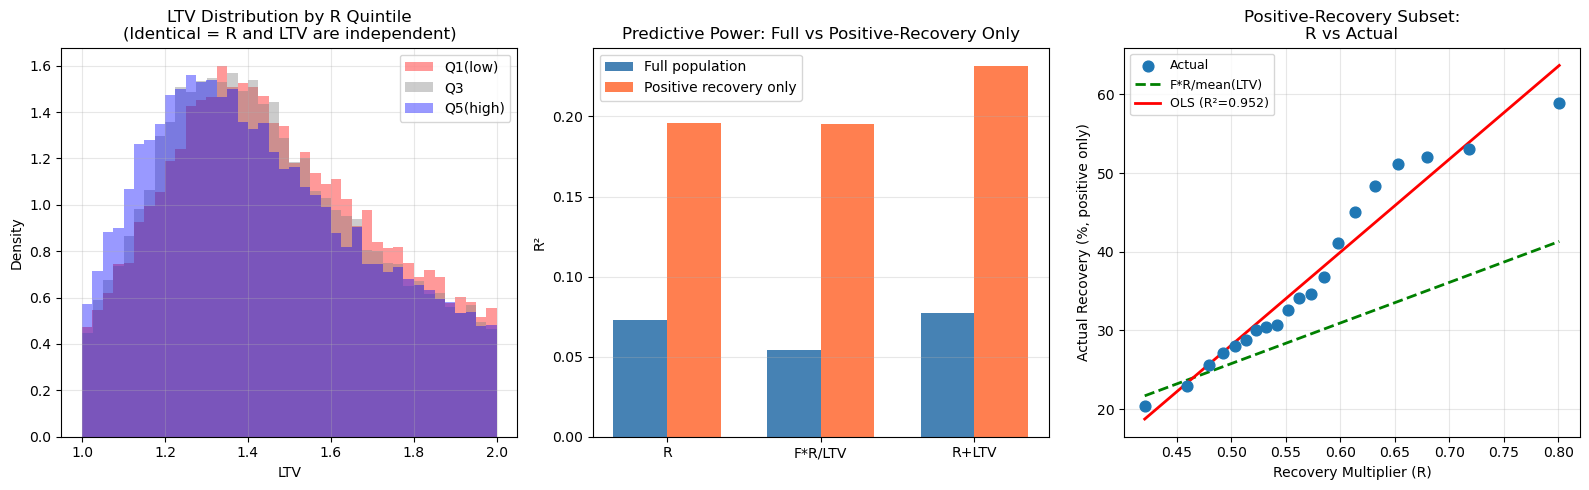

In [21]:
# =============================================================================
# TEST 8: LTV distribution within R bins + unbinned loan-level comparison
# Q1: Is LTV identically distributed across R levels?
# Q2: Raw loan-level R² without any binning (M3 vs ratio)
# Q3: Does R/LTV work better on positive-recovery-only subset?
# =============================================================================

print("=" * 90)
print("TEST 8: LTV DISTRIBUTION ACROSS R QUINTILES + UNBINNED R²")
print("=" * 90)

# --- Q1: LTV distribution within R quintiles ---
co_valid['R_q5'] = pd.qcut(co_valid['new_recovery_multiplier'], q=5,
                            labels=['Q1(low)', 'Q2', 'Q3', 'Q4', 'Q5(high)'])

print(f"\n  Q1: LTV DISTRIBUTION WITHIN EACH R QUINTILE")
print(f"  (If identical → dividing by LTV is dividing by pure noise)")
print(f"  {'-'*75}")
print(f"  {'R Quintile':<12} {'N':>7} {'Mean LTV':>9} {'Median LTV':>11} {'Std LTV':>8} "
      f"{'P10':>6} {'P90':>6}")
print(f"  {'-'*75}")

for q in ['Q1(low)', 'Q2', 'Q3', 'Q4', 'Q5(high)']:
    subset = co_valid[co_valid['R_q5'] == q]
    ltv_vals = subset['ltv']
    print(f"  {q:<12} {len(subset):>7,} {ltv_vals.mean():>9.4f} {ltv_vals.median():>11.4f} "
          f"{ltv_vals.std():>8.4f} {ltv_vals.quantile(0.1):>6.3f} {ltv_vals.quantile(0.9):>6.3f}")

# KS test: are the LTV distributions the same across R quintiles?
from scipy.stats import ks_2samp
q1_ltv = co_valid[co_valid['R_q5'] == 'Q1(low)']['ltv'].values
q5_ltv = co_valid[co_valid['R_q5'] == 'Q5(high)']['ltv'].values
ks_stat, ks_p = ks_2samp(q1_ltv, q5_ltv)
print(f"\n  KS test (Q1 vs Q5 LTV distributions): stat={ks_stat:.4f}, p={ks_p:.2e}")
if ks_p > 0.05:
    print(f"  → Cannot reject that LTV distributions are identical across R extremes.")
else:
    print(f"  → Distributions are statistically different (but effect size matters).")
    print(f"     Mean LTV diff (Q5-Q1): {q5_ltv.mean() - q1_ltv.mean():+.4f} "
          f"(~{abs(q5_ltv.mean() - q1_ltv.mean()) / q1_ltv.std() * 100:.1f}% of a std)")

# --- Q2: Raw loan-level R² (no binning) ---
print(f"\n{'='*90}")
print(f"  Q2: UNBINNED LOAN-LEVEL R² (raw correlations, no models beyond OLS)")
print(f"{'='*90}")

y = co_valid['recovery_pct'].values
R_vals = co_valid['new_recovery_multiplier'].values
LTV_vals = co_valid['ltv'].values
ratio_vals = (F * R_vals / LTV_vals)

# Raw Pearson correlations (r² = R² for single-predictor OLS)
r_R = np.corrcoef(R_vals, y)[0, 1]
r_LTV = np.corrcoef(LTV_vals, y)[0, 1]
r_ratio = np.corrcoef(ratio_vals, y)[0, 1]

print(f"\n  {'Predictor':<25} {'Pearson r':>10} {'r² (= loan-level R²)':>22}")
print(f"  {'-'*60}")
print(f"  {'R':<25} {r_R:>+10.5f} {r_R**2:>22.5f}")
print(f"  {'LTV':<25} {r_LTV:>+10.5f} {r_LTV**2:>22.5f}")
print(f"  {'F*R/LTV':<25} {r_ratio:>+10.5f} {r_ratio**2:>22.5f}")
print(f"\n  Interpretation:")
print(f"    R alone: r²={r_R**2:.5f}")
print(f"    F*R/LTV: r²={r_ratio**2:.5f}")
print(f"    Difference: {r_ratio**2 - r_R**2:+.5f} (ratio is {'better' if r_ratio**2 > r_R**2 else 'worse'})")
print(f"\n    M3 (R+LTV, 2 predictors): R²={models['M3: Additive (R + LTV)']['r2']:.5f}")
print(f"    This is strictly the loan-level result — no binning, no aggregation.")

# --- Q3: Positive-recovery only ---
print(f"\n{'='*90}")
print(f"  Q3: POSITIVE-RECOVERY SUBSET ONLY (recovery > 0)")
print(f"  If R/LTV works where the theory applies (vehicle found & sold):")
print(f"{'='*90}")

co_pos = co_valid[co_valid['recovery_pct'] > 0].copy()
co_zero = co_valid[co_valid['recovery_pct'] == 0].copy()

print(f"\n  Population split:")
print(f"    Zero recovery:     {len(co_zero):>8,} ({len(co_zero)/len(co_valid):.1%})")
print(f"    Positive recovery: {len(co_pos):>8,} ({len(co_pos)/len(co_valid):.1%})")
print(f"    Mean recovery (pos only): {co_pos['recovery_pct'].mean():.4f} ({co_pos['recovery_pct'].mean()*100:.1f}%)")

y_pos = co_pos['recovery_pct'].values
R_pos = co_pos['new_recovery_multiplier'].values
LTV_pos = co_pos['ltv'].values
ratio_pos = F * R_pos / LTV_pos

# Single-predictor R² on positive-only
r_R_pos = np.corrcoef(R_pos, y_pos)[0, 1]
r_LTV_pos = np.corrcoef(LTV_pos, y_pos)[0, 1]
r_ratio_pos = np.corrcoef(ratio_pos, y_pos)[0, 1]

# Multi-predictor OLS
lr_m3_pos = LinearRegression().fit(np.column_stack([R_pos, LTV_pos]), y_pos)
r2_m3_pos = r2_score(y_pos, lr_m3_pos.predict(np.column_stack([R_pos, LTV_pos])))

lr_ratio_pos = LinearRegression().fit(ratio_pos.reshape(-1, 1), y_pos)
r2_ratio_pos = r2_score(y_pos, lr_ratio_pos.predict(ratio_pos.reshape(-1, 1)))

print(f"\n  {'Predictor':<25} {'r² (full pop)':>14} {'r² (pos only)':>14} {'Change':>10}")
print(f"  {'-'*67}")
print(f"  {'R':<25} {r_R**2:>14.5f} {r_R_pos**2:>14.5f} {r_R_pos**2 - r_R**2:>+10.5f}")
print(f"  {'LTV':<25} {r_LTV**2:>14.5f} {r_LTV_pos**2:>14.5f} {r_LTV_pos**2 - r_LTV**2:>+10.5f}")
print(f"  {'F*R/LTV':<25} {r_ratio**2:>14.5f} {r_ratio_pos**2:>14.5f} {r_ratio_pos**2 - r_ratio**2:>+10.5f}")
print(f"  {'R + LTV (M3)':<25} {models['M3: Additive (R + LTV)']['r2']:>14.5f} {r2_m3_pos:>14.5f} "
      f"{r2_m3_pos - models['M3: Additive (R + LTV)']['r2']:>+10.5f}")

print(f"\n  Key comparison (positive-recovery only):")
print(f"    R alone:   r² = {r_R_pos**2:.5f}")
print(f"    F*R/LTV:   r² = {r_ratio_pos**2:.5f}")
print(f"    R + LTV:   R² = {r2_m3_pos:.5f}")
ratio_vs_R_pos = r_ratio_pos**2 - r_R_pos**2
print(f"    Ratio vs R: {ratio_vs_R_pos:+.5f}")

if r_ratio_pos**2 > r_R_pos**2:
    print(f"\n  FINDING: F*R/LTV OUTPERFORMS R on positive-recovery subset!")
    print(f"  The ratio works where the theory applies (vehicle found & recovered).")
    print(f"  The full-population failure is driven by zero-recovery loans where")
    print(f"  dividing by LTV amplifies prediction errors.")
else:
    print(f"\n  FINDING: R still beats F*R/LTV even on positive-recovery loans.")
    print(f"  The ratio theory doesn't hold even conditional on recovery occurring.")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: LTV distribution by R quintile (overlaid histograms)
ax = axes[0]
for q, color in zip(['Q1(low)', 'Q3', 'Q5(high)'], ['red', 'gray', 'blue']):
    subset = co_valid[co_valid['R_q5'] == q]
    ax.hist(subset['ltv'], bins=40, alpha=0.4, density=True, label=q, color=color)
ax.set_xlabel('LTV')
ax.set_ylabel('Density')
ax.set_title('LTV Distribution by R Quintile\n(Identical = R and LTV are independent)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel B: R² comparison full vs positive-only
ax = axes[1]
labels = ['R', 'F*R/LTV', 'R+LTV']
full_r2 = [r_R**2, r_ratio**2, models['M3: Additive (R + LTV)']['r2']]
pos_r2 = [r_R_pos**2, r_ratio_pos**2, r2_m3_pos]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, full_r2, width, label='Full population', color='steelblue')
ax.bar(x + width/2, pos_r2, width, label='Positive recovery only', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('R²')
ax.set_title('Predictive Power: Full vs Positive-Recovery Only')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Panel C: Ratio vs R on positive-only (binned)
co_pos['R_bin_pos'] = pd.qcut(co_pos['new_recovery_multiplier'], q=20, duplicates='drop')
by_R_pos = co_pos.groupby('R_bin_pos', observed=True).agg(
    R_mid=('new_recovery_multiplier', 'mean'),
    ratio_mid=('fr_over_ltv', 'mean'),
    actual=('recovery_pct', 'mean'),
).dropna()

ax = axes[2]
ax.scatter(by_R_pos['R_mid'], by_R_pos['actual'] * 100, s=60, zorder=3, label='Actual')
ax.plot(by_R_pos['R_mid'], F * by_R_pos['R_mid'] * 100 / co_pos['ltv'].mean(), 'g--',
        linewidth=2, label=f'F*R/mean(LTV)')
slope_p, int_p, r_p, _, _ = linregress(by_R_pos['R_mid'], by_R_pos['actual'])
ax.plot(by_R_pos['R_mid'], (int_p + slope_p * by_R_pos['R_mid']) * 100, 'r-',
        linewidth=2, label=f'OLS (R²={r_p**2:.3f})')
ax.set_xlabel('Recovery Multiplier (R)')
ax.set_ylabel('Actual Recovery (%, positive only)')
ax.set_title('Positive-Recovery Subset:\nR vs Actual')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ltv_distribution_and_positive_recovery.png', dpi=150, bbox_inches='tight')
plt.show()

TEST 8b: ARE ZERO-RECOVERY CHARGEOFFS JUST IMMATURE LOANS?

  Recovery Rate by Book Year (chargeoffs only, maturity cutoff <= 2023-12-31)
  --------------------------------------------------------------------------------
    Year  N Chargeoffs  % w/ Recovery   % Zero  Mean Recov%   Mean R
  --------------------------------------------------------------------------------
    2020        34,247         41.8%    58.2%       16.29%   0.5774
    2021        54,336         46.2%    53.8%       18.64%   0.5749
    2022        35,811         49.4%    50.6%       15.53%   0.5452
    2023        22,177         50.8%    49.2%       16.84%   0.5455

  Zero-Recovery Rate by Book Quarter:
  -------------------------------------------------------
  Quarter           N  % Zero Recovery  Mean Recov%
  -------------------------------------------------------
  2020Q1        9,335           58.6%       15.59%
  2020Q2        7,818           58.2%       16.53%
  2020Q3        9,680           58.2%       16


  SEASONING FILTER: book_date <= 2022-06-30
  Mature population: 109,465
  Zero recovery rate (mature): 54.5%
  (vs 53.3% in full population)

  R² COMPARISON ON MATURE LOANS (book <= 2022-06-30):
  Predictor              All Mature  Pos-Only Mature
  ----------------------------------------------------
  R                         0.08843          0.22091
  F*R/LTV                   0.05788          0.19141
  R + LTV                   0.09104          0.24579

  Mature positive-recovery: 49,770 (45.5%)


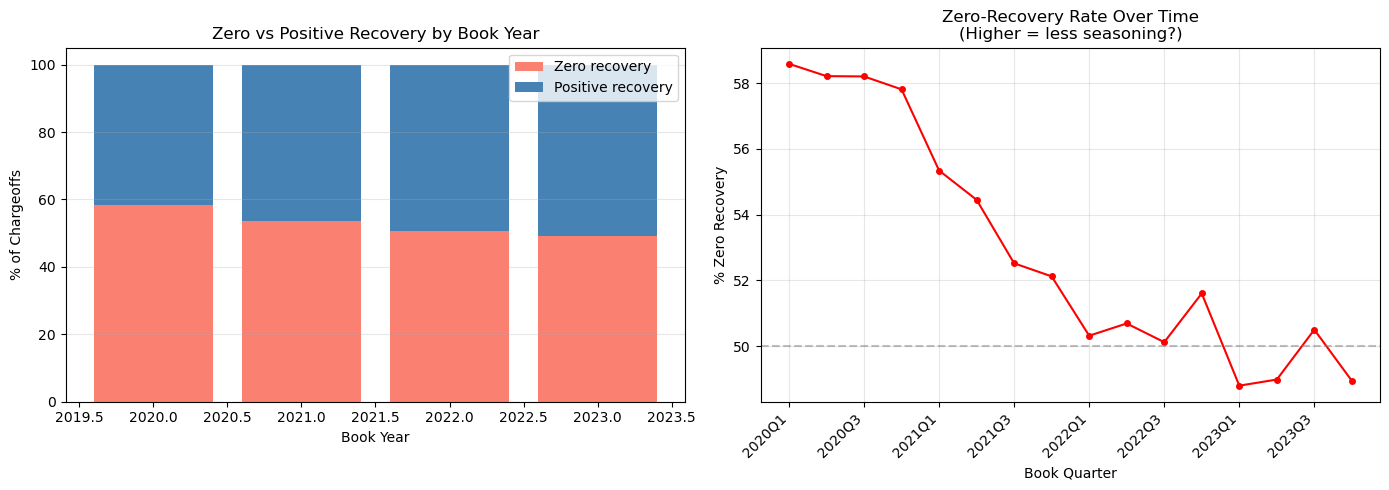

In [22]:
# =============================================================================
# TEST 8b: Date distribution of zero vs positive recovery chargeoffs
# Are zero-recovery loans just immature (too recent to have recovered)?
# =============================================================================

co_valid['book_date_dt'] = pd.to_datetime(co_valid['book_date'])
co_valid['has_recovery'] = (co_valid['recovery_pct'] > 0).astype(int)

print("=" * 90)
print("TEST 8b: ARE ZERO-RECOVERY CHARGEOFFS JUST IMMATURE LOANS?")
print("=" * 90)

# Distribution by year
co_valid['book_year'] = co_valid['book_date_dt'].dt.year
by_year = co_valid.groupby('book_year').agg(
    n_total=('account_number', 'count'),
    n_positive=('has_recovery', 'sum'),
    mean_recovery=('recovery_pct', 'mean'),
    mean_R=('new_recovery_multiplier', 'mean'),
).reset_index()
by_year['pct_positive'] = by_year['n_positive'] / by_year['n_total']
by_year['pct_zero'] = 1 - by_year['pct_positive']

print(f"\n  Recovery Rate by Book Year (chargeoffs only, maturity cutoff <= 2023-12-31)")
print(f"  {'-'*80}")
print(f"  {'Year':>6} {'N Chargeoffs':>13} {'% w/ Recovery':>14} {'% Zero':>8} "
      f"{'Mean Recov%':>12} {'Mean R':>8}")
print(f"  {'-'*80}")
for _, row in by_year.iterrows():
    print(f"  {int(row['book_year']):>6} {int(row['n_total']):>13,} "
          f"{row['pct_positive']:>13.1%} {row['pct_zero']:>8.1%} "
          f"{row['mean_recovery']*100:>11.2f}% {row['mean_R']:>8.4f}")

# Distribution by quarter
co_valid['book_quarter'] = co_valid['book_date_dt'].dt.to_period('Q').astype(str)
by_quarter = co_valid.groupby('book_quarter').agg(
    n_total=('account_number', 'count'),
    n_positive=('has_recovery', 'sum'),
    mean_recovery=('recovery_pct', 'mean'),
).reset_index()
by_quarter['pct_zero'] = 1 - by_quarter['n_positive'] / by_quarter['n_total']

print(f"\n  Zero-Recovery Rate by Book Quarter:")
print(f"  {'-'*55}")
print(f"  {'Quarter':<10} {'N':>8} {'% Zero Recovery':>16} {'Mean Recov%':>12}")
print(f"  {'-'*55}")
for _, row in by_quarter.iterrows():
    print(f"  {row['book_quarter']:<10} {int(row['n_total']):>8,} "
          f"{row['pct_zero']:>15.1%} {row['mean_recovery']*100:>11.2f}%")

# Compare zero vs positive recovery: book date stats
zero_dates = co_valid[co_valid['has_recovery'] == 0]['book_date_dt']
pos_dates = co_valid[co_valid['has_recovery'] == 1]['book_date_dt']

print(f"\n  Book Date Summary:")
print(f"  {'':>25} {'Zero Recovery':>15} {'Positive Recovery':>18}")
print(f"  {'-'*60}")
print(f"  {'Mean book date':<25} {str(zero_dates.mean().date()):>15} {str(pos_dates.mean().date()):>18}")
print(f"  {'Median book date':<25} {str(zero_dates.median().date()):>15} {str(pos_dates.median().date()):>18}")
print(f"  {'Min':<25} {str(zero_dates.min().date()):>15} {str(pos_dates.min().date()):>18}")
print(f"  {'Max':<25} {str(zero_dates.max().date()):>15} {str(pos_dates.max().date()):>18}")

# If there's a clear seasoning effect, re-run the R² comparison on mature-only
# (e.g., book_date <= 2022-12-31 to ensure 12+ months post-chargeoff seasoning)
SEASONING_CUTOFF = '2022-06-30'
co_mature = co_valid[co_valid['book_date_dt'] <= SEASONING_CUTOFF].copy()
mature_zero_pct = (co_mature['recovery_pct'] == 0).mean()

print(f"\n  SEASONING FILTER: book_date <= {SEASONING_CUTOFF}")
print(f"  Mature population: {len(co_mature):,}")
print(f"  Zero recovery rate (mature): {mature_zero_pct:.1%}")
print(f"  (vs {(co_valid['recovery_pct'] == 0).mean():.1%} in full population)")

# Re-run key R² comparison on mature loans
if len(co_mature) > 1000:
    y_m = co_mature['recovery_pct'].values
    R_m = co_mature['new_recovery_multiplier'].values
    LTV_m = co_mature['ltv'].values
    ratio_m = F * R_m / LTV_m

    r_R_m = np.corrcoef(R_m, y_m)[0, 1]
    r_ratio_m = np.corrcoef(ratio_m, y_m)[0, 1]
    r_LTV_m = np.corrcoef(LTV_m, y_m)[0, 1]

    lr_m3_m = LinearRegression().fit(np.column_stack([R_m, LTV_m]), y_m)
    r2_m3_m = r2_score(y_m, lr_m3_m.predict(np.column_stack([R_m, LTV_m])))

    # Positive-only on mature
    co_mature_pos = co_mature[co_mature['recovery_pct'] > 0]
    y_mp = co_mature_pos['recovery_pct'].values
    R_mp = co_mature_pos['new_recovery_multiplier'].values
    LTV_mp = co_mature_pos['ltv'].values
    ratio_mp = F * R_mp / LTV_mp

    r_R_mp = np.corrcoef(R_mp, y_mp)[0, 1]
    r_ratio_mp = np.corrcoef(ratio_mp, y_mp)[0, 1]
    lr_m3_mp = LinearRegression().fit(np.column_stack([R_mp, LTV_mp]), y_mp)
    r2_m3_mp = r2_score(y_mp, lr_m3_mp.predict(np.column_stack([R_mp, LTV_mp])))

    print(f"\n  R² COMPARISON ON MATURE LOANS (book <= {SEASONING_CUTOFF}):")
    print(f"  {'Predictor':<20} {'All Mature':>12} {'Pos-Only Mature':>16}")
    print(f"  {'-'*52}")
    print(f"  {'R':<20} {r_R_m**2:>12.5f} {r_R_mp**2:>16.5f}")
    print(f"  {'F*R/LTV':<20} {r_ratio_m**2:>12.5f} {r_ratio_mp**2:>16.5f}")
    print(f"  {'R + LTV':<20} {r2_m3_m:>12.5f} {r2_m3_mp:>16.5f}")
    print(f"\n  Mature positive-recovery: {len(co_mature_pos):,} ({len(co_mature_pos)/len(co_mature):.1%})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(by_year['book_year'], by_year['pct_zero'] * 100, color='salmon', label='Zero recovery')
ax.bar(by_year['book_year'], by_year['pct_positive'] * 100, bottom=by_year['pct_zero'] * 100,
       color='steelblue', label='Positive recovery')
ax.set_xlabel('Book Year')
ax.set_ylabel('% of Chargeoffs')
ax.set_title('Zero vs Positive Recovery by Book Year')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.plot(range(len(by_quarter)), by_quarter['pct_zero'] * 100, 'r-o', markersize=4)
ax.set_xticks(range(0, len(by_quarter), 2))
ax.set_xticklabels(by_quarter['book_quarter'].iloc[::2], rotation=45, ha='right')
ax.set_xlabel('Book Quarter')
ax.set_ylabel('% Zero Recovery')
ax.set_title('Zero-Recovery Rate Over Time\n(Higher = less seasoning?)')
ax.grid(True, alpha=0.3)
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('zero_recovery_seasoning.png', dpi=150, bbox_inches='tight')
plt.show()

TEST 8c: ZERO RECOVERY BY PREDICTED VEHICLE VALUE (R * BlackBook)

  If costs (repo + transport + auction) ≈ $2-3K, vehicles below that
  threshold should have near-100% zero recovery rate.

  Predicted vehicle value = R * bbvalue
  Population: 146,571 chargeoffs

  Value Bucket        N  % Zero Recov  Mean Recov%  Mean R  Mean BB$  Mean LTV
  --------------------------------------------------------------------------------
  <$500               2       100.0%        0.00%   0.423 $     913     1.578
  $500-1K            41        85.4%        2.68%   0.516 $   1,656     1.667
  $1K-2K            497        71.6%        6.54%   0.495 $   3,410     1.677
  $2K-3K          2,716        63.4%        8.15%   0.498 $   5,333     1.736
  $3K-4K          7,820        58.3%        9.73%   0.506 $   7,176     1.718
  $4K-5K         13,978        56.0%       11.17%   0.517 $   8,888     1.665
  $5K-7.5K       46,096        53.1%       14.99%   0.546 $  11,699     1.537
  $7.5K-10K      36,743    


  R² on HIGH-VALUE vehicles (>= $5K predicted):
    R alone:   0.06223
    F*R/LTV:   0.04145
    R + LTV:   0.06483


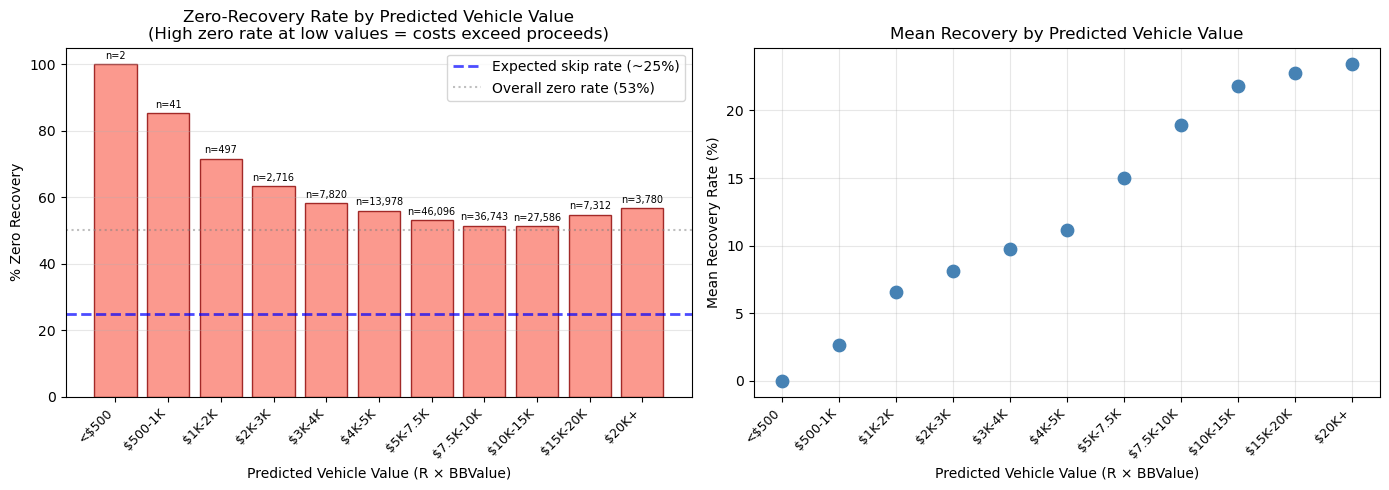

In [23]:
# =============================================================================
# TEST 8c: Do low-value vehicles explain zero recovery?
# R * bbvalue = predicted vehicle value at chargeoff
# If this is below repo/transport/auction costs (~$2-3K), net recovery = 0
# =============================================================================

co_valid['pred_vehicle_value'] = co_valid['new_recovery_multiplier'] * co_valid['bbvalue']
co_valid['has_recovery'] = (co_valid['recovery_pct'] > 0).astype(int)

# Define value buckets
value_bins = [0, 500, 1000, 2000, 3000, 4000, 5000, 7500, 10000, 15000, 20000, np.inf]
value_labels = ['<$500', '$500-1K', '$1K-2K', '$2K-3K', '$3K-4K', '$4K-5K',
                '$5K-7.5K', '$7.5K-10K', '$10K-15K', '$15K-20K', '$20K+']

co_valid['value_bucket'] = pd.cut(co_valid['pred_vehicle_value'], bins=value_bins,
                                   labels=value_labels, right=False)

by_value = co_valid.groupby('value_bucket', observed=True).agg(
    n=('account_number', 'count'),
    pct_zero=('has_recovery', lambda x: 1 - x.mean()),
    mean_recovery_pct=('recovery_pct', 'mean'),
    mean_R=('new_recovery_multiplier', 'mean'),
    mean_bbvalue=('bbvalue', 'mean'),
    mean_ltv=('ltv', 'mean'),
).reset_index()

print("=" * 90)
print("TEST 8c: ZERO RECOVERY BY PREDICTED VEHICLE VALUE (R * BlackBook)")
print("=" * 90)
print(f"\n  If costs (repo + transport + auction) ≈ $2-3K, vehicles below that")
print(f"  threshold should have near-100% zero recovery rate.")
print(f"\n  Predicted vehicle value = R * bbvalue")
print(f"  Population: {len(co_valid):,} chargeoffs")

print(f"\n  {'Value Bucket':<12} {'N':>8} {'% Zero Recov':>13} {'Mean Recov%':>12} "
      f"{'Mean R':>7} {'Mean BB$':>9} {'Mean LTV':>9}")
print(f"  {'-'*80}")

for _, row in by_value.iterrows():
    print(f"  {row['value_bucket']:<12} {int(row['n']):>8,} {row['pct_zero']:>12.1%} "
          f"{row['mean_recovery_pct']*100:>11.2f}% {row['mean_R']:>7.3f} "
          f"${row['mean_bbvalue']:>8,.0f} {row['mean_ltv']:>9.3f}")

# Cumulative: what fraction of ALL zeros come from low-value vehicles?
total_zeros = (co_valid['recovery_pct'] == 0).sum()
print(f"\n  Total zero-recovery chargeoffs: {total_zeros:,}")
print(f"\n  Cumulative share of zeros by value threshold:")
print(f"  {'Threshold':<20} {'Zeros below':>12} {'% of all zeros':>15} {'Cum % of pop':>13}")
print(f"  {'-'*63}")

for thresh in [500, 1000, 2000, 3000, 4000, 5000, 7500, 10000]:
    below = co_valid[co_valid['pred_vehicle_value'] < thresh]
    zeros_below = (below['recovery_pct'] == 0).sum()
    pct_of_zeros = zeros_below / total_zeros
    pct_of_pop = len(below) / len(co_valid)
    print(f"  {'< $' + f'{thresh:,}':<20} {zeros_below:>12,} {pct_of_zeros:>14.1%} {pct_of_pop:>12.1%}")

# What's the zero-recovery rate for vehicles ABOVE $5K? (should be lower, ~skip rate)
above_5k = co_valid[co_valid['pred_vehicle_value'] >= 5000]
above_5k_zero_rate = (above_5k['recovery_pct'] == 0).mean()
above_10k = co_valid[co_valid['pred_vehicle_value'] >= 10000]
above_10k_zero_rate = (above_10k['recovery_pct'] == 0).mean()

print(f"\n  Zero-recovery rate for high-value vehicles:")
print(f"    Predicted value >= $5K:  {above_5k_zero_rate:.1%} (N={len(above_5k):,})")
print(f"    Predicted value >= $10K: {above_10k_zero_rate:.1%} (N={len(above_10k):,})")
print(f"    (If skip rate ≈ 25%, high-value zeros should approach ~25%)")

# --- Re-test R vs R/LTV on high-value-only subset ---
high_val = co_valid[co_valid['pred_vehicle_value'] >= 5000].copy()
y_hv = high_val['recovery_pct'].values
R_hv = high_val['new_recovery_multiplier'].values
LTV_hv = high_val['ltv'].values
ratio_hv = F * R_hv / LTV_hv

r_R_hv = np.corrcoef(R_hv, y_hv)[0, 1]
r_ratio_hv = np.corrcoef(ratio_hv, y_hv)[0, 1]
lr_m3_hv = LinearRegression().fit(np.column_stack([R_hv, LTV_hv]), y_hv)
r2_m3_hv = r2_score(y_hv, lr_m3_hv.predict(np.column_stack([R_hv, LTV_hv])))

print(f"\n  R² on HIGH-VALUE vehicles (>= $5K predicted):")
print(f"    R alone:   {r_R_hv**2:.5f}")
print(f"    F*R/LTV:   {r_ratio_hv**2:.5f}")
print(f"    R + LTV:   {r2_m3_hv:.5f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = range(len(by_value))
bars = ax.bar(x_pos, by_value['pct_zero'] * 100, color='salmon', edgecolor='darkred', alpha=0.8)
ax.axhline(25, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Expected skip rate (~25%)')
ax.axhline(50, color='gray', linestyle=':', alpha=0.5, label='Overall zero rate (53%)')
ax.set_xticks(x_pos)
ax.set_xticklabels(value_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Predicted Vehicle Value (R × BBValue)')
ax.set_ylabel('% Zero Recovery')
ax.set_title('Zero-Recovery Rate by Predicted Vehicle Value\n(High zero rate at low values = costs exceed proceeds)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
# Annotate counts
for i, (bar, row) in enumerate(zip(bars, by_value.itertuples())):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={row.n:,.0f}', ha='center', va='bottom', fontsize=7)

ax = axes[1]
ax.scatter(by_value['value_bucket'].cat.codes, by_value['mean_recovery_pct'] * 100,
           s=80, zorder=3, color='steelblue')
ax.set_xticks(range(len(value_labels)))
ax.set_xticklabels(value_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Predicted Vehicle Value (R × BBValue)')
ax.set_ylabel('Mean Recovery Rate (%)')
ax.set_title('Mean Recovery by Predicted Vehicle Value')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zero_recovery_by_vehicle_value.png', dpi=150, bbox_inches='tight')
plt.show()

TEST 8d: GROSS LOSS FOR ZERO vs POSITIVE RECOVERY CHARGEOFFS

  Gross Loss Distribution:
                                   Zero Recovery  Positive Recovery
  -----------------------------------------------------------------
  N                                       78,150             68,378
  Mean gross_loss_amt            $        16,520 $           18,322
  Median gross_loss_amt          $        16,440 $           17,590
  P10                            $         3,523 $           10,562
  P25                            $        10,930 $           13,791
  P75                            $        21,398 $           21,620
  P90                            $        27,004 $           26,425
  Mean net_loss_amt              $        16,520 $           10,500
  Mean proceeds                  $        20,770 $           20,767
  Mean amt_financed              $        20,770 $           20,767

  Gross loss distribution for ZERO-RECOVERY loans:
  Threshold                        N  % of 

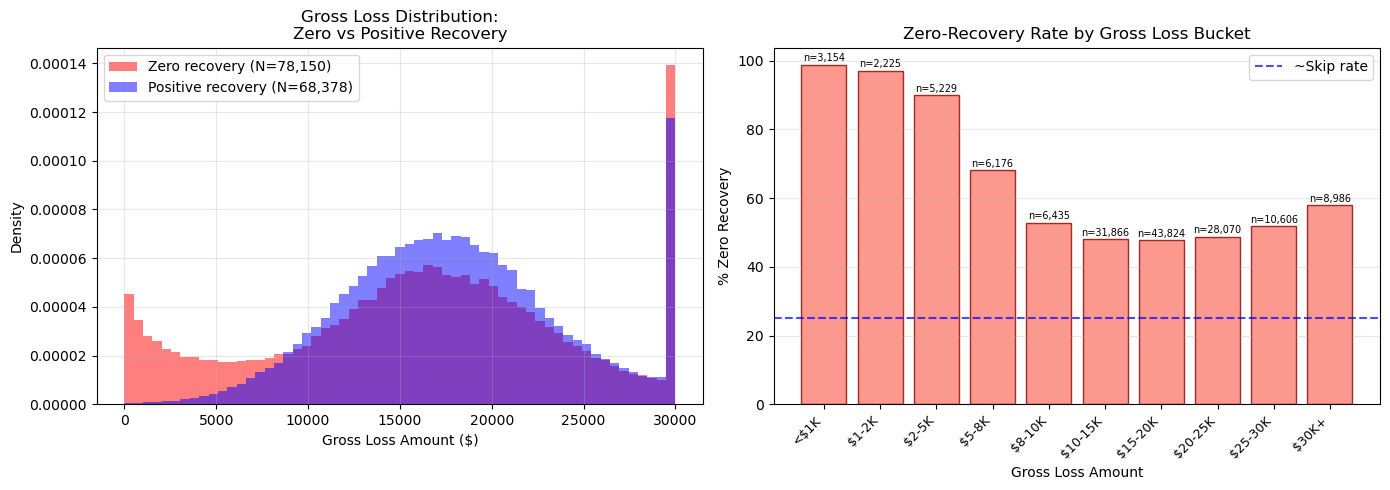

In [24]:
# =============================================================================
# TEST 8d: Gross loss distribution for zero vs positive recovery
# Are zero-recovery chargeoffs just low-balance loans that were nearly paid off?
# =============================================================================

print("=" * 90)
print("TEST 8d: GROSS LOSS FOR ZERO vs POSITIVE RECOVERY CHARGEOFFS")
print("=" * 90)

zero = co_valid[co_valid['recovery_pct'] == 0].copy()
pos = co_valid[co_valid['recovery_pct'] > 0].copy()

print(f"\n  Gross Loss Distribution:")
print(f"  {'':>30} {'Zero Recovery':>15} {'Positive Recovery':>18}")
print(f"  {'-'*65}")
print(f"  {'N':<30} {len(zero):>15,} {len(pos):>18,}")
print(f"  {'Mean gross_loss_amt':<30} ${zero['gross_loss_amt'].mean():>14,.0f} ${pos['gross_loss_amt'].mean():>17,.0f}")
print(f"  {'Median gross_loss_amt':<30} ${zero['gross_loss_amt'].median():>14,.0f} ${pos['gross_loss_amt'].median():>17,.0f}")
print(f"  {'P10':<30} ${zero['gross_loss_amt'].quantile(0.1):>14,.0f} ${pos['gross_loss_amt'].quantile(0.1):>17,.0f}")
print(f"  {'P25':<30} ${zero['gross_loss_amt'].quantile(0.25):>14,.0f} ${pos['gross_loss_amt'].quantile(0.25):>17,.0f}")
print(f"  {'P75':<30} ${zero['gross_loss_amt'].quantile(0.75):>14,.0f} ${pos['gross_loss_amt'].quantile(0.75):>17,.0f}")
print(f"  {'P90':<30} ${zero['gross_loss_amt'].quantile(0.9):>14,.0f} ${pos['gross_loss_amt'].quantile(0.9):>17,.0f}")
print(f"  {'Mean net_loss_amt':<30} ${zero['net_loss_amt'].mean():>14,.0f} ${pos['net_loss_amt'].mean():>17,.0f}")
print(f"  {'Mean proceeds':<30} ${zero['proceeds'].mean():>14,.0f} ${pos['proceeds'].mean():>17,.0f}")
print(f"  {'Mean amt_financed':<30} ${zero['amt_financed'].mean():>14,.0f} ${pos['amt_financed'].mean():>17,.0f}")

# Check: what % of zero-recovery loans have gross_loss < various thresholds?
print(f"\n  Gross loss distribution for ZERO-RECOVERY loans:")
print(f"  {'Threshold':<25} {'N':>8} {'% of zeros':>11}")
print(f"  {'-'*47}")
for thresh in [0, 100, 500, 1000, 2000, 5000]:
    n_below = (zero['gross_loss_amt'] <= thresh).sum()
    print(f"  {'gross_loss <= $' + f'{thresh:,}':<25} {n_below:>8,} {n_below/len(zero):>10.1%}")

# Does gross_loss = net_loss for zero recovery? (i.e., recovery = GL - NL = 0)
zero['gl_equals_nl'] = np.isclose(zero['gross_loss_amt'], zero['net_loss_amt'], atol=1)
print(f"\n  Zero recovery: gross_loss ≈ net_loss?")
print(f"    Yes (within $1): {zero['gl_equals_nl'].sum():,} ({zero['gl_equals_nl'].mean():.1%})")
print(f"    No:              {(~zero['gl_equals_nl']).sum():,} ({(~zero['gl_equals_nl']).mean():.1%})")

# For high-value vehicles with zero recovery — are they low gross loss?
high_val_zero = co_valid[(co_valid['pred_vehicle_value'] >= 10000) &
                          (co_valid['recovery_pct'] == 0)]
high_val_pos = co_valid[(co_valid['pred_vehicle_value'] >= 10000) &
                         (co_valid['recovery_pct'] > 0)]

print(f"\n  HIGH-VALUE vehicles (predicted >= $10K):")
print(f"  {'':>30} {'Zero Recovery':>15} {'Positive Recovery':>18}")
print(f"  {'-'*65}")
print(f"  {'N':<30} {len(high_val_zero):>15,} {len(high_val_pos):>18,}")
print(f"  {'Mean gross_loss_amt':<30} ${high_val_zero['gross_loss_amt'].mean():>14,.0f} ${high_val_pos['gross_loss_amt'].mean():>17,.0f}")
print(f"  {'Median gross_loss_amt':<30} ${high_val_zero['gross_loss_amt'].median():>14,.0f} ${high_val_pos['gross_loss_amt'].median():>17,.0f}")
print(f"  {'Mean net_loss_amt':<30} ${high_val_zero['net_loss_amt'].mean():>14,.0f} ${high_val_pos['net_loss_amt'].mean():>17,.0f}")
print(f"  {'Mean pred vehicle value':<30} ${high_val_zero['pred_vehicle_value'].mean():>14,.0f} ${high_val_pos['pred_vehicle_value'].mean():>17,.0f}")
print(f"  {'Gross loss <= $1000':<30} {(high_val_zero['gross_loss_amt'] <= 1000).mean():>14.1%} "
      f"{(high_val_pos['gross_loss_amt'] <= 1000).mean():>17.1%}")
print(f"  {'Gross loss <= $5000':<30} {(high_val_zero['gross_loss_amt'] <= 5000).mean():>14.1%} "
      f"{(high_val_pos['gross_loss_amt'] <= 5000).mean():>17.1%}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins_hist = np.linspace(0, 30000, 60)
ax.hist(zero['gross_loss_amt'].clip(upper=30000), bins=bins_hist, alpha=0.5,
        density=True, label=f'Zero recovery (N={len(zero):,})', color='red')
ax.hist(pos['gross_loss_amt'].clip(upper=30000), bins=bins_hist, alpha=0.5,
        density=True, label=f'Positive recovery (N={len(pos):,})', color='blue')
ax.set_xlabel('Gross Loss Amount ($)')
ax.set_ylabel('Density')
ax.set_title('Gross Loss Distribution:\nZero vs Positive Recovery')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
# Zero rate by gross loss bucket
gl_bins = [0, 1000, 2000, 5000, 8000, 10000, 15000, 20000, 25000, 30000, np.inf]
gl_labels = ['<$1K', '$1-2K', '$2-5K', '$5-8K', '$8-10K', '$10-15K',
             '$15-20K', '$20-25K', '$25-30K', '$30K+']
co_valid['gl_bucket'] = pd.cut(co_valid['gross_loss_amt'], bins=gl_bins, labels=gl_labels, right=False)
by_gl = co_valid.groupby('gl_bucket', observed=True).agg(
    n=('account_number', 'count'),
    pct_zero=('has_recovery', lambda x: 1 - x.mean()),
).reset_index()

ax.bar(range(len(by_gl)), by_gl['pct_zero'] * 100, color='salmon', edgecolor='darkred', alpha=0.8)
ax.set_xticks(range(len(by_gl)))
ax.set_xticklabels(gl_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Gross Loss Amount')
ax.set_ylabel('% Zero Recovery')
ax.set_title('Zero-Recovery Rate by Gross Loss Bucket')
ax.axhline(25, color='blue', linestyle='--', alpha=0.7, label='~Skip rate')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, row in by_gl.iterrows():
    ax.text(i, row['pct_zero'] * 100 + 1, f'n={row["n"]:,.0f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('gross_loss_zero_recovery.png', dpi=150, bbox_inches='tight')
plt.show()